# T5 Probing and Fine-Tuning
> Thorsten Trinkaus

---
## Imports
---

In [1]:
import datasets
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import json
import os
from tqdm.auto import tqdm
from transformers.modeling_outputs import BaseModelOutput
from transformers import (
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    AutoTokenizer, 
    T5ForConditionalGeneration,
    Adafactor,
    get_constant_schedule_with_warmup
)
from dataclasses import dataclass, field
from typing import Dict
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay

---
---
## Probing


The first step is to introduce some basic helper functions for probing the T5
model. These functions will help us convert data inputs into tokenized model
inputs, provide multiple ways of probing the model, and visualize the results.

### Helper Functions

In [2]:
# Functions to retrieve the label spaces of the different datasets.

def onto_labels():
    """Return OntoNotes labels."""
    return ["person", "location", "organization", "misc"]

def figer_labels_list():
    """
    Return FIGER labels, by looking at the figer mapping file.

    Returns:
        A list of labels in the dataset.
    """

    labels = set()

    # Try to load the mapping file.
    try:
        with open("datasets/figer/types.map", "r") as f:
            for line in tqdm(f, desc="Processing mapping file"):

                entries = line.strip().split("\t")
                _, figer_type = entries

                # Skip the first empty part.
                parts = figer_type.split("/")[1:]

                label = []

                for part in parts:
                    # Edit some of the labels to better work with natural
                    # language.
                    if part == "livingthing":
                        part = "living thing"
                    elif "_" in part:
                        part = part.replace("_", " ")

                    label.append(part)

                labels.add(tuple(label))
            
            return sorted(labels)

    except FileNotFoundError:
        raise FileNotFoundError(
            "File not found. Make sure datasets/figer/types.map exists."
        )

def figer_labels():
    """
    Return FIGER labels, by looking at the figer mapping file.

    Returns:
        A tree structure, since FIGER labels are hierarchical.
    """

    # The tree of labels.
    label_tree = {}

    # Try to load the mapping file.
    try:
        with open("datasets/figer/types.map", "r") as f:
            for line in tqdm(f, desc="Processing mapping file"):

                entries = line.strip().split("\t")
                _, figer_type = entries

                # Skip the first empty part.
                parts = figer_type.split("/")[1:]

                current_dict = label_tree
                for part in parts:
                    # Edit some of the labels to better work with natural
                    # language.
                    if part == "livingthing":
                        part = "living thing"
                    elif "_" in part:
                        part = part.replace("_", " ")

                    if part not in current_dict:
                        current_dict[part] = {}
                    current_dict = current_dict[part]
            
            return label_tree

    except FileNotFoundError:
        raise FileNotFoundError(
            "File not found. Make sure datasets/figer/types.map exists."
        )

def ultra_labels():
    """
    Return Ultra Fine labels.

    Returns:
        A list of labels in the dataset.
    """
    with open("datasets/ultra_fine/types.txt", "r") as f:
        types = f.read().splitlines()
        for i, t in enumerate(types):
            if "_" in t:
                types[i] = t.replace("_", " ")
    return types

# Functions to convert the different datasets into a single format
# that can be processed by functions down the line.

def onto2sample(ds, num_proc=1, masking_strategy="none"):
    """
    Convert a OntoNotes dataset split into our data format. This function converts
    samples with multiple mentions into multiple samples with a single mention each.
    
    Args:
        ds: The dataset split to convert.
        num_proc: The number of processes to use for the conversion.
        masking_strategy: Whether to use masking and what to mask. This can be
        "none", "mention", or "context".

    Returns:
        A list of samples in the format:
        {
            "text": The text of  the sample,
            "mention": The mention in the text,
            "label": The label of the mention
        }
    """

    def update_ds(batch, masking_strategy=masking_strategy):
        """
        Update the dataset to our format. This function enables us to use
        ds.map().
        
        Args:
            batch: A batch of samples from the dataset.
            masking_strategy: The masking strategy.
        
        Returns:
            A batch of samples in our format.
        """

        def retrieve_mention(tokens, ner_tags, i):
            """
            Retrieve the mention that starts at index i.
            
            Args:
                tokens: The list of tokens.
                ner_tags: The list of NER tags for these tokens.
                i: Start index of the mention.
            
            Returns:
                The mention as a single string and the index of the last token
                in the mention.
            """
            mention = tokens[i]
            tag = ner_tags[i]
            while i + 1 < len(tokens) and ner_tags[i + 1] == tag + 1:
                mention += " " + tokens[i + 1]
                i += 1
            return mention, i
        
        texts = []
        mentions = []
        labels = []
        for tokens, tags in zip(batch["tokens"], batch["ner_tags"]):
            
            # Nothing should be masked. Text can be generated once for all
            # mentions within.
            if masking_strategy == "none":
                text = " ".join(tokens).strip()

            # Check each token to find mentions.
            for i, tag in enumerate(tags):
                # 1, 3, 5, and 7 are the B- tags.
                if tag in [1, 3, 5, 7]:

                    mention, end = retrieve_mention(tokens, tags, i)

                    # Mask mention.
                    if masking_strategy == "mention":
                        text = ""
                        
                        # Text does not start with mention.
                        if i > 0:
                            text += " ".join(tokens[:i])

                        text += " <extra_id_1> "

                        # Text does not end with mention.
                        if end + 1 < len(tokens):
                            text += " ".join(tokens[end + 1:])

                        text = text.strip()

                    # Mask context.
                    elif masking_strategy == "context":
                        text = ""

                        # Text does not start with mention.
                        if i > 0:
                            text = "<extra_id_1> "

                        text += mention

                        # Text does not end with mention.
                        if end + 1 < len(tokens):
                            text += " <extra_id_2>"

                        text = text.strip()

                    # OntoNotes labels.
                    label = (
                        "person" if tag == 1 else 
                        "location" if tag == 3 else 
                        "organization" if tag == 5 else 
                        "misc"
                    )

                    texts.append(text)
                    mentions.append(
                        mention 
                        if masking_strategy != "mention" 
                        else "<extra_id_1>"
                    )
                    labels.append(label)

        return {
            "text": texts,
            "mention": mentions,
            "labels": labels
        }

    return ds.map(
        lambda batch: update_ds(batch, masking_strategy=masking_strategy),
        batched=True, 
        remove_columns=ds.column_names,
          num_proc=num_proc
    )

def figer2sample(ds, num_proc=1, masking_strategy="none"):
    """
    Convert a FIGER dataset split into our data format.
    
    Args:
        ds: The dataset split to convert.
        num_proc: The number of processes to use for the conversion.
        masking_strategy: Whether to use masking and what to mask. This can be
        "none", "mention", or "context".

    Returns:
        A list of samples in the format:
        {
            "text": The text of  the sample,
            "mention": The mention in the text,
            "labels": The labels of the mention in a set
        }
    """

    def update_ds(batch, masking_strategy=masking_strategy):
        """
        Update the dataset to our format. This function enables us to use
        ds.map().
        
        Args:
            batch: A batch of samples from the dataset.
        
        Returns:
            A batch of samples in our format.
        """

        texts = []
        mentions = []
        labels = []

        for tokens, start, end, labels_ in zip(
            batch["tokens"],
            batch["start"],
            batch["end"], 
            batch["labels"]
        ):
            # Retrieve mention.
            if masking_strategy == "mention":
                mention = "<extra_id_1>"
            else:
                mention = " ".join(tokens[start:end]).strip()

            text = ""

            if start > 0:
                if masking_strategy == "context":
                    text += "<extra_id_1> "
                else:
                    text += " ".join(tokens[:start]) + " "

            text += mention

            if end < len(tokens):
                if masking_strategy == "context":
                    text += " <extra_id_2>"
                else:
                    text += " " + " ".join(tokens[end:])
                
            text = text.strip()

            # Build label set for the mention.
            label_set = set()

            for label in labels_:
                parts = label.split("/")[1:]  # Skip the first empty part.
                label_tuple = []
                for part in parts:
                    # Edit some of the labels to better work with natural
                    # language.
                    if part == "livingthing":
                        part = "living thing"
                    elif "_" in part:
                        part = part.replace("_", " ")

                    label_tuple.append(part)
                label_set.add(tuple(label_tuple))

            

            texts.append(text)
            mentions.append(mention)
            labels.append(label_set)

        return {
            "text": texts,
            "mention": mentions,
            "labels": labels
        }

    return ds.map(
        lambda batch: update_ds(batch, masking_strategy=masking_strategy),
        batched=True, 
        remove_columns=ds.column_names,
          num_proc=num_proc
    )

def ultra2sample(ds, num_proc=1, masking_strategy="none"):
    """
    Convert an Ultra-Fine dataset split into our data format.
    
    Args:
        ds: The dataset split to convert.
        num_proc: The number of processes to use for the conversion.
        masking_strategy: Whether to use masking and what to mask. This can be
        "none", "mention", or "context".


    Returns:
        A list of samples in the format:
        {
            "text": The text of  the sample,
            "mention": The mention in the text,
            "labels": The labels of the mention in tree structure
        }
    """

    def update_ds(batch, masking_strategy=masking_strategy):
        """
        Update the dataset to our format. This function enables us to use
        ds.map().
        
        Args:
            batch: A batch of samples from the dataset.
        
        Returns:
            A batch of samples in our format.
        """
        
        texts = []
        mentions = []
        labels = []

        for left_tokens, right_tokens, mention, labels_ in zip(
            batch["left_context_token"],
            batch["right_context_token"],
            batch["mention_span"],
            batch["y_str"]
        ):
            left_text = " ".join(left_tokens).strip()
            right_text = " ".join(right_tokens).strip()

            if masking_strategy == "mention":
                mention = "<extra_id_1>"
            elif masking_strategy == "context":
                if len(left_text) > 0:
                    left_text = "<extra_id_1>"
                if len(right_text) > 0:
                    right_text = "<extra_id_2>"

            text = f"{left_text} {mention} {right_text}".strip()

            true_labels = set()
            for label in labels_:
                if "_" in label:
                    label = label.replace("_", " ")
                true_labels.add(label)

            texts.append(text)
            mentions.append(mention)
            labels.append(true_labels)

        return {
            "text": texts,
            "mention": mentions,
            "labels": labels
        }

    return ds.map(
        update_ds, 
        batched=True, 
        remove_columns=ds.column_names,
          num_proc=num_proc
    )

def sample2prompt(samples, allow_multiple_labels=False, figer=False):
    """
    Convert our samples to T5 prompts. This function can process single samples
    or a list of samples.

    Args:
        samples: A sample or a list of samples.
        allow_multiple_labels: Whether to allow multiple labels in the prompt.
        This parameter changes the wording of the prompt.
        figer: A specific flag for FIGER evaluation. If True, the prompt will
        contain the coarse labels for each fine label.

    Returns:
        A list of prompts for the samples. It will return a list even if a
        single sample is provided.
    """
    if isinstance(samples, dict):
        samples = [samples]

    coarse = []
  
    for s in samples:
        if figer:
            mention_labels = []
            for label in s["labels"]:
                if len(label) == 2:
                    mention_labels.append(label[0])
            coarse.append(mention_labels)
        else:
            coarse.append([])

    if allow_multiple_labels:
        return [
            f"{(
                s["text"].strip()
                + ("" if s["text"].strip().endswith((".", "!", "?")) else ".")
            )} "
            f"The entity types of \"{s["mention"].strip()}\" are {', '.join(c).strip()}, <extra_id_0>."
            for s, c in zip(samples, coarse)
        ]
    
    return [
        f"{(
            s["text"].strip()
            + ("" if s["text"].strip().endswith((".", "!", "?")) else ".")
        )} "
        f"The entity type of \"{s["mention"].strip()}\" is <extra_id_0>."
        for s in samples
    ]

Now, we can implement our first inference function. This function takes the
label space and tests each label with each sample in the datset, to find the
most likely label for each sample. This score is achieved by comparing the
logits of the model for each (sample, label) pair.

In [3]:
def run_inference(
        X_test, 
        label_space, 
        model, 
        tokenizer, 
        batch_size=8, 
        allow_multiple_labels=False, 
        multiple_labels_margin=0.1
):
    """
    Run inference on the test set with the provided model and tokenizer. 
    
    Args:
        X_test: The test set of samples.
        label_space: The list of possible labels.
        model: The T5 model to use for inference.
        tokenizer: The T5 tokenizer.
        batch_size: Batch size to use for inference.
        allow_multiple_labels: Whether to allow multiple predicted labels per
        sample.
        multiple_labels_margin: The margin within which to consider multiple
        scores as valid labels.
    
    Returns:
        A list of results.
    """

    # Ensure X_test is a list for indexing.
    X_test = list(X_test)

    # Setup device and model.
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Running inference on {device}.")

    model =  model.to(device).eval()

    num_labels = len(label_space)

    with torch.inference_mode():

        # Precompute label encodings, since the label space is fixed.
        print("Computing label encodings.")

        candidate_targets = [f"<extra_id_0> {label} <extra_id_1>" for label in label_space]
        target_encoding = tokenizer(
            candidate_targets,
            return_tensors="pt",
            padding=True
        )
        target_ids = target_encoding.input_ids.to(device)

        # Mask padding tokens in target_ids to -100, so they can be ignored in
        # loss computation.
        target_mask = target_encoding.attention_mask.to(device).bool()
        labels = target_ids.masked_fill(~target_mask, -100)

        # True token lengths of each label sequence.
        label_lengths = target_mask.sum(dim=1).clamp_min(1)

        # Decoder input ids can be precomputed once, since they are the shifted labels.
        decoder_input_ids = model._shift_right(labels)

        # Prebuild prompts from samples.
        prompts = sample2prompt(X_test, allow_multiple_labels)

        results = []

        print(f"Starting inference with batch size {batch_size}.")

        for start in tqdm(range(0, len(X_test), batch_size)):
            # Create batch.
            batch_samples = X_test[start:start + batch_size]
            batch_prompts = prompts[start:start + batch_size]

            # Tokenize prompts.
            encoding = tokenizer(
                batch_prompts,
                return_tensors="pt",
                padding=True,
                truncation=True
            )

            input_ids = encoding.input_ids.to(device, non_blocking=True)
            # Attention mask, since we are padding inputs.
            attention_mask = encoding.attention_mask.to(device, non_blocking=True)

            # Batch size for this iteration.
            bsz = input_ids.size(0)

            encoder_outputs = model.encoder(
                input_ids=input_ids,
                attention_mask=attention_mask,
                return_dict=True
            )

            # Retrieve the last hidden state.
            enc_hidden = encoder_outputs.last_hidden_state
            # The length of the token sequence dimension.
            seq_len = enc_hidden.size(1)
            # Hidden Size.
            hidden_dim = enc_hidden.size(2)
            # The length of the attention mask sequence dimension.
            attn_len = attention_mask.size(1)

            # Repeat encoder outputs across labels to process all labels in a
            # single forward pass.
            enc_hidden = (
                enc_hidden[:, None, :, :]               
                .expand(bsz, num_labels, seq_len, hidden_dim)
                .reshape(bsz * num_labels, seq_len, hidden_dim)
            )

            expanded_attention_mask = (
                attention_mask[:, None, :]
                .expand(bsz, num_labels, attn_len)
                .reshape(bsz * num_labels, attn_len)
            )

            expanded_decoder_input_ids = (
                decoder_input_ids.unsqueeze(0)
                .expand(bsz, num_labels, -1)
                .reshape(bsz * num_labels, -1)
            )

            expanded_labels = (
                labels.unsqueeze(0)
                .expand(bsz, num_labels, -1)
                .reshape(bsz * num_labels, -1)
            )

            expanded_label_mask = (
                target_mask.unsqueeze(0)
                .expand(bsz, num_labels, -1)
                .reshape(bsz * num_labels, -1)
            )

            expanded_label_lengths = (
                label_lengths.unsqueeze(0)
                .expand(bsz, num_labels)
                .reshape(bsz * num_labels)
            )

            # Forward pass through the model.
            out = model(
                encoder_outputs=BaseModelOutput(last_hidden_state=enc_hidden),
                attention_mask=expanded_attention_mask,
                decoder_input_ids=expanded_decoder_input_ids,
                use_cache=False,
                return_dict=True
            )

            # Compute log probabilities.
            log_probs = F.log_softmax(out.logits, dim=-1)

            # .gather() retrieves the log probabilities of the correct
            # labels, but does not work with -100, so we mask these values
            # to 0.
            safe_labels = expanded_labels.masked_fill(~expanded_label_mask, 0)
            token_scores = log_probs.gather(
                dim=2,
                index=safe_labels.unsqueeze(-1)
            ).squeeze(-1)

            # Zero out padding token scores and sum token scores.
            seq_scores = (token_scores * expanded_label_mask).sum(dim=1)
            # Normalize by the true label lengths to avoid bias towards shorter
            # labels.
            norm_scores = seq_scores / expanded_label_lengths

            if allow_multiple_labels:
                # Find the best score.
                best_scores, best_idx = norm_scores.view(bsz, num_labels).max(dim=1)
                # Retrieve all labels within the margin of the best score.
                best_idx = [
                    [i for i, score in enumerate(sample_scores) if score >= best_score - multiple_labels_margin]
                    for sample_scores, best_score in zip(norm_scores.view(bsz, num_labels), best_scores)
                ]
                # Retrieve labels themselves.
                predicted_labels = [
                    [label_space[i] for i in sample_idx] for sample_idx in best_idx
                ]

            else:
                # Retrieve only the index of the best label for each sample.
                best_idx = norm_scores.view(bsz, num_labels).argmax(dim=1).tolist()
                # Retrieve labels themselves.
                predicted_labels = [label_space[i] for i in best_idx]
            
            for sample, pred_labels in zip(batch_samples, predicted_labels):
                results.append({
                    "text": sample["text"],
                    "mention": sample["mention"],
                    "predicted_label": pred_labels,
                    "true_labels": sample["labels"]
                })

    return results

Scoring labels instead of letting the model generate is a fast and efficient way to probe the model without touching its vocabulary. Nethertheless, it requires us to process every combination of N input samples and M labels, which is highly computationally expensive if the label spaces is large (e.g., 10k+ labels in the case of Ultra-Fine). We, therefore, require a second way of model inference, which does not scale with the label space size. This second menthod works by letting the model generate freely, but limiting the vocabulary the model can generate from. Since, the model generates single tokens at a time and labels can span multiple tokens, we need to limit the vocabulary at each generated token, such that the model can only generate valid label sequences. To achieve this goal, we introduce a Trie data structure to represent the tokenized label space.

In [4]:
# First, we need a representation of a single node in the Trie. Each node
# represents a single token id, with a dictionary of child nodes, which
# represent the possible next token ids in the label space.

@dataclass
class TokenNode:
    # Dict[int, TokenNode]: Maps token ids to their corresponding child nodes.
    children: Dict[int, "TokenNode"] = field(default_factory=dict)
    # Is this node the end of a valid label sequence?
    is_end: bool = False


# Next, we can implement the Trie itself.

class TokenTrie:
    def __init__(self):
        # The root does not represent any token itself, but is the starting
        # point for all sequences.
        self.root = TokenNode()

    def insert(self, token_ids):
        """
        Insert a sequence of token ids into the Trie.

        Args:
            token_ids: A list of token ids. This list should represent a single
            label, as the last id will be marked as the end of a valid label sequence.
        """
        
        # Start at root.
        current_node = self.root

        # Insert one id at a time.
        for token_id in token_ids:

            # Insert a new node if the id is not a child of the current node.
            if token_id not in current_node.children:
                current_node.children[token_id] = TokenNode()

            # Move to the next node.
            current_node = current_node.children[token_id]
        
        # The sequence of ids is fully inserted, so we mark the node as the end
        # of a valid label sequence.
        current_node.is_end = True

T5 is pre-trained for span reconstruction of natural language text, so,
while probing the model, we need to provide the next tokens in the most natural
way possible. We can not just generate a sequence
of labels, but require some seperator that is incerted between the labels to
generate a natural listing of labels. To keep the setup as simple as possible,
we simply use a "," as seperator between labels. To tell the model at each
generation step which tokens are ok to generate, we introduce a constraint
class, which decides which tokens are allowed based on the previously generated tokens.

In [5]:
class LabelConstraint:
    def __init__(
        self,
        trie,
        sep_ids,
        eos_id,
        extra_id_0,
        extra_id_1,
        decoder_start_id = None,
        max_labels = None
    ):
        """
        Args:
            trie: The label Trie.
            sep_ids: The token ids that should seperate labels.
            eos_id: The token id that should be generated to end the generation
            process.
            extra_id_0: The token id of <extra_id_0>, because the model is trained
            to generate the span reconstruction between <extra_id_0> and <extra_id_1>.
            extra_id_1: The token id of <extra_id_1>.
            decoder_start_id: The token id that the decoder starts with.
            max_labels: The maximum number of labels to generate. If None, the model
            can generate until the token limit is reached.
        """
        self.trie = trie
        self.sep_ids = sep_ids
        self.eos_id = eos_id
        self.extra_id_0 = extra_id_0
        self.extra_id_1 = extra_id_1
        self.decoder_start_id = decoder_start_id
        self.max_labels = max_labels

    def _strip_start(self, generated):
        """
        Strips the decoder start token (and if present, the id for <extra_id_0>)
        from the current generated sequence. This function removes these ids,
        since they are not part of the label trie.
        
        Args:
            generated: The generated token ids.
        
        Returns:
            The ids without the decoder start token and <extra_id_0> id. This
            function also returns a boolean indicating whether it removed a
            <extra_id_0> token. This information is relevant since the model
            should only start generating labels after this token.
        """
        has_extra_id_0 = False
        
        # Is there a decoder start token at the beginning of the sequence?
        if (
            len(generated) > 0 
            and self.decoder_start_id is not None
            and generated[0] == self.decoder_start_id
        ):
            generated = generated[1:]
        
        # Is there and <extra_id_0> token at the beginning of the new sequence?
        if len(generated) > 0 and generated[0] == self.extra_id_0:
            generated = generated[1:]
            has_extra_id_0 = True
        
        return generated, has_extra_id_0

    def _parse_prefix(self, generated):
        """
        This function effectively implements a state machine that parses the
        tokens generated so far and decides which labels where generated,
        whether a separator should be inserted next, and whether the generation
        process can (or should) end. If in the middle of a label sequence, this
        function finds the relevant node in the label trie, which dictates the
        next valid token ids.

        Args:
            generated: The generated token ids.
        """

        # Remove decoder token (and <extra_id_0) from the sequence.
        generated, has_extra_id_0 = self._strip_start(generated)

        # Start at root.
        node = self.trie.root

        # There are 2 different modes:
        # "label": Next, a label should follow
        # "sep": In the middle of a separator
        mode = "label"

        # This variable is only relevant if the separator spans multiple tokens
        # (this is not the case with ",", but this allows us to test multiple
        # posible separators). It is used in "sep" mode and indicates how many
        # of the separator tokens have been generated yet.
        sep_pos = 0

        # The ids of the current label in the sequence. This variable helps to
        # keep track of what labels have been generated.
        current_label = []

        # A set of completed labels. These labels can not be generated again.
        completed = set()

        # Process each of the previously generated token ids.
        for tok_id in generated:

            # Currently at a label.
            if mode == "label":

                # Move along the trie as long as possible.
                if tok_id in node.children:
                    node = node.children[tok_id]
                    # Add the node id to the current label.
                    current_label.append(tok_id)
                    continue

                # Could this be the end of a label? Note that is_end does not
                # necessarily mean an end of a label, since some labels can be
                # prefixes of others (e.g., "body" and "body of water").
                if node.is_end:
                    current_tuple = tuple(current_label)

                    # Did the model generate self.extra_1_id? If yes, the
                    # generation finished and the only allowed token should be
                    # eos, so we can stop.
                    if (
                        tok_id == self.extra_id_1
                        and current_tuple not in completed
                    ):
                            return {
                                "valid": True,
                                "finished": True
                            }

                    # Did we arrive at the start of a separator? If yes, the
                    # current label ended and can be marked as completed.
                    if (
                        current_tuple not in completed
                        and len(self.sep_ids) > 0
                        and tok_id == self.sep_ids[0]
                    ):
                        # The current label is now completed, so return to
                        # the trie root.
                        completed.add(current_tuple)
                        node = self.trie.root
                        current_label = []

                        # If the separator is a single token, we can move on to
                        # the next label. Else, we need to change to "sep" mode
                        # to move past the separator tokens.
                        if len(self.sep_ids) > 1:
                            mode = "sep"
                            sep_pos = 1
                        
                        continue

                # If this point is reached, something went wrong while generating.
                return {"valid": False}

            else: # mode == "sep"
                
                # If a separator started, but the generated tokens do not match
                # the separator, something went wrong.
                if tok_id != self.sep_ids[sep_pos]:
                    return {"valid": False}

                # Move forward.
                sep_pos += 1

                # if the end of the separator is reached, return to the "label"
                # mode.
                if sep_pos == len(self.sep_ids):
                    mode = "label"
                    sep_pos = 0

        # At the end of the generated sequence, return the current state of the
        # state machine to guide the next generation step.
        return {
            "valid": True,
            "finished": False,
            "mode": mode,
            "node": node,
            "completed": completed,
            "current_label": tuple(current_label),
            "has_extra_id_0": has_extra_id_0
        }

    def _has_available_completion(self, node, prefix, completed):
        """
        This function checks whether there is a valid label sequence in the trie
        that starts with the prefix and is not in the completed set. This
        function is necessary, since labels can be prefixes of each other (e.g.,
        should the model end the label "body" or can it continue to "body of water").
        
        Args:
            node: The current node in the trie.
            prefix: The current label prefix to check.
            completed: The set of completed labels.

        Returns:
            Whether there is a valid completion.
        """
        # If the current node is the end of a valid label sequence and this
        # label is not already completed, this label is a valid completion.
        if node.is_end and prefix not in completed:
            return True
        
        # Recursively check if there is a valid completion in the children nodes.
        for tok_id, child in node.children.items():
            if self._has_available_completion(child, prefix + (tok_id,), completed):
                return True
        
        return False

    def allowed_tokens(self, batch_id, input_ids):
        """
        This is the main function of the constraint class, which will be passed
        to the model during generation to decide the next allowed tokens, which
        explains the parameters of this function.
        
        Args:
            batch_id: Not relevant for this function.
            input_ids: The token ids generated so far.
        """
        # First, parse the generated tokens. input_ids is a tensor.
        parse = self._parse_prefix(input_ids.tolist())

        # If something went wrong.
        if not parse["valid"]:
            raise RuntimeError(
                f"Invalid generation sequence: {input_ids.tolist()}"
            )

        # Generation finished. Only allow eos.
        if parse["finished"]:
            return [self.eos_id]

        # If the generation is in the middle of a separator, only allow the next
        # token in the separator.
        if parse["mode"] == "sep":
            return [self.sep_ids[parse["sep_pos"]]]

        # If the model has not yet generated the <extra_id_0> token, only allow
        # this token.
        if not parse["has_extra_id_0"]:
            return [self.extra_id_0]

        # Otherwise, the allowed tokens depend on the current node and which
        # labels are already completed.
        allowed = []
        node = parse["node"]
        completed = parse["completed"]
        current_label = parse["current_label"]

        # Check each next token in the trie.
        for tok_id, child in node.children.items():
            if (
                self._has_available_completion(
                    child, 
                    current_label + (tok_id,), 
                    completed
                )
            ):
                allowed.append(tok_id)

        # If the current node is the end of a valid label, allow the model to
        # end the generation (by generating <extra_id_1>).
        if node.is_end and current_label not in completed:
            allowed.append(self.extra_id_1)

            # Did the number of generated labels reach the maximum? If no, allow
            # the separator to be generated. This is only possible if there is
            # still another label that can be generated, so we need to check if
            # _has_available_completion is True if we complete the current label.
            count_if_closed = len(completed) + 1
            if (
                (self.max_labels is None
                or count_if_closed < self.max_labels)
                and len(self.sep_ids) > 0
            ):
                completed_if_closed = set(completed)
                completed_if_closed.add(current_label)

                if (
                    self._has_available_completion(
                        self.trie.root, 
                        tuple(), 
                        completed_if_closed
                    )
                ):
                    allowed.append(self.sep_ids[0])

        # Safty check to ensure we do not return an empty list.
        if len(allowed) == 0:
            raise RuntimeError(
                f"No valid continuation: "
                f"{input_ids.tolist()}"
            )

        return sorted(set(allowed))

The only component that is left is the inference function itself.

In [6]:
def run_inference_with_generation(
    X_test, 
    label_space, 
    model, 
    tokenizer, 
    batch_size=8,
    num_beams=1,
    max_new_tokens=100,
    max_labels=10,
    fjger=False
):
    """
    Run inference on the test set with the provided model and tokenizer. 
    
    Args:
        X_test: The test set of samples.
        label_space: The list of possible labels.
        model: The T5 model to use for inference.
        tokenizer: The T5 tokenizer.
        batch_size: Batch size to use for inference.
        num_beams: The number of beams to use for beam search. 1 equals no beam
        search (i.e., greedy decoding).
        max_new_tokens: The maximum number of new tokens to generate.
        max_labels: The maximum number of labels to generate.
        figer: A specific flag for FIGER evaluation. If True, the prompt will
        contain the coarse labels for each fine label.
    
    Returns:
        A list of results.
    """

    # Ensure X_test is a list for indexing.
    X_test = list(X_test)

    # Setup device and model.
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Running inference on {device}.")

    model =  model.to(device).eval()

    results = []

    with torch.inference_mode():

        print("Building label trie.")

        # Label token id sequences.
        label_seqs = [
            tokenizer(label, add_special_tokens=False).input_ids
            for label in label_space
        ]
        trie = TokenTrie()
        for seq in label_seqs:
            trie.insert(seq)

        # This is the token id of ",". Through testing, we found that using the
        # tokenizer on ",", it produces [3, 6], but only if it is tokenized
        # alone (i.e., not as part of a larger string with labels in it). This
        # difference caused some issues during testing, so this value is
        # hardcoded for now.
        sep_ids = [6]

        eos_id = tokenizer.eos_token_id
        pad_id = tokenizer.pad_token_id
        extra_0_id = tokenizer.convert_tokens_to_ids("<extra_id_0>")
        extra_1_id = tokenizer.convert_tokens_to_ids("<extra_id_1>")

        # Get constraint instance.
        constraint = LabelConstraint(
            trie=trie,
            sep_ids=sep_ids,
            eos_id=eos_id,
            extra_id_0=extra_0_id,
            extra_id_1=extra_1_id,
            decoder_start_id=pad_id,
            max_labels=max_labels
        )

        # Tokenize all the prompts once.
        print("Tokenizing prompts.")

        if max_labels == 1:
            prompts = sample2prompt(X_test, allow_multiple_labels=False)
        else:
            # The figer setting only makes sense with multiple labels.
            prompts = sample2prompt(X_test, allow_multiple_labels=True, figer=fjger)


        input_encodings = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
        )

        input_ids = input_encodings.input_ids
        attention_mask = input_encodings.attention_mask

        # Generate labels in batches.
        for i in tqdm(range(0, len(prompts), batch_size), desc="Generating"):
            # Create batch.
            batch_samples = X_test[i:i + batch_size]
            batch_input_ids = input_ids[i:i + batch_size].to(model.device)
            batch_attention_mask = attention_mask[i:i + batch_size].to(model.device)

            # Parameter explanation:
            # do_sample=False: Disable randomness, for better reproducibility.
            # stop_strings="<extra_id_1>": Stop generation when the model
            # generates the <extra_id_1> string. For this to work, we pass the
            # tokenizer to the model!
            # prefix_allowed_tokens_fn=constraint.allowed_tokens: Here, we pass
            # our constraint function to restrict the generation.
            outputs = model.generate(
                input_ids=batch_input_ids,
                attention_mask=batch_attention_mask,
                do_sample=False,
                max_new_tokens=max_new_tokens,
                num_beams=num_beams,
                tokenizer=tokenizer,
                stop_strings="<extra_id_1>",
                prefix_allowed_tokens_fn=constraint.allowed_tokens
            )

            # Decode the generated tokens.
            batch_decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)

            for sample, decoded in zip(batch_samples, batch_decoded):

                # Stplit the decoded labels.
                predicted = [label.strip() for label in decoded.split(",")]

                results.append({
                        "text": sample["text"],
                        "mention": sample["mention"],
                        "predicted_label": predicted,
                        "true_labels": sample["labels"]
                    })

        return results

---
---
## Fine-Tuning

To fine-tune the model, we need some helper functions to convert the data from
our sample format into the format required for T5 fine-tuning. The following
functions help to achieve these goals:
- convert the labels of each sample into a single target string
- map each sample to a T5 input format, which consists of input_ids,
  attention_mask, and labels, where the label target string is tokenized
- train the model

In [7]:
def sample2target(ds, tokenizer, num_proc=1, sample2prompt=sample2prompt):
    """
    Convert a dataset split in our sample format to the target format for model
    training.
    
    Args:
        ds: The dataset split to convert.
        tokenizer: The tokenizer.
        num_proc: The number of processes to use for the conversion. This can
        speed up when processing large datasets.
        sample2prompt: Function to convert a sample to a prompt.
    """

    def update_ds(batch, tokenizer, sample2prompt):
        """
        Update the dataset to the target format. This function enables us to use
        ds.map().
        
        Args:
            batch: A batch of samples from the dataset.
            tokenizer: The tokenizer.
        Returns:
            A batch of samples in the target format.
        """

        def labels2target(labels):
            """
            Converts a label (or a list of labels) to the target
            format for model training.
            
            Args:
                labels: Labels to convert.

            Returns:
                The target string.
            """
            # Target is a single label.
            if isinstance(labels, str):
                return f"<extra_id_0> {labels} <extra_id_1></s>"

            # Target is a list of labels.
            label_str = "<extra_id_0> " + labels[0]
            for l in labels[1:]:
                label_str += ", " + l
            label_str += " <extra_id_1></s>"
            return label_str


        input_ids = []
        attention_mask = []
        labels = []

        for text, mention, labels_ in zip(
            batch["text"], 
            batch["mention"], 
            batch["labels"]
        ):
            sample = {
                "text": text,
                "mention": mention,
                "labels": labels_
            }

            if isinstance(labels_, str):
                prompt = sample2prompt(sample, allow_multiple_labels=False)[0]
            else:
                prompt = sample2prompt(sample, allow_multiple_labels=True)[0]
            target = labels2target(labels_)

            source = tokenizer(
                prompt,
                truncation=True,
                max_length=256,
            )

            target = tokenizer(
                target,
                truncation=True,
                max_length=64,
            )

            source["labels"] = target.input_ids

            input_ids.append(source["input_ids"])
            attention_mask.append(source["attention_mask"])
            labels.append(source["labels"])

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }

    
    return ds.map(
        lambda batch: update_ds(batch, tokenizer, sample2prompt),
        batched=True, 
        remove_columns=ds.column_names,
        num_proc=num_proc
    )

In [8]:
def train_T5(
    model,
    tokenizer,
    X_train,
    X_dev,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=1e-4,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    predict_with_generate=True,
    logging_steps=100,
    output_dir="./T5-trained"
):
    """
    Train a T5 model on the provided training and validation sets.

    Args:
        model: The model to train.
        tokenizer: The tokenizer.
        X_train: The training set.
        X_dev: The validation set.
        per_device_train_batch_size: The batch size to use for training.
        per_device_eval_batch_size: The batch size to use for evaluation.
        learning_rate: The learning rate to use for training. The T5
        documentation suggests a slightly higher learning rate than the default.
        (We use 1e-4 by default).
        num_train_epochs: The number of epochs to train for.
        weight_decay: The weight decay to use for training.
        eval_strategy: The evaluation strategy to use.
        save_strategy: The saving strategy to use.
        predict_with_generate: Whether to use generate() for evaluation. This
        depends on the inference method used.
        logging_steps: The number of steps between logging training metrics.
        output_dir: The directory to save the trained model and training logs.
    """

    # Setup model.
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    model.train()
    print("Training model on device:", device)

    # Setup data collator. 
    data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

    use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
    
    # Setup arguments for trainer.
    training_args = Seq2SeqTrainingArguments(
        output_dir=output_dir,
        per_device_train_batch_size=per_device_train_batch_size,
        per_device_eval_batch_size=per_device_eval_batch_size,
        learning_rate=learning_rate,
        num_train_epochs=num_train_epochs,
        weight_decay=weight_decay,
        eval_strategy=eval_strategy,
        save_strategy=save_strategy,
        predict_with_generate=predict_with_generate,
        logging_steps=logging_steps,
        bf16=use_bf16,
        fp16=(torch.cuda.is_available() and not use_bf16),
        max_grad_norm=0.0
    )

    optimizer = Adafactor(
        model.parameters(),
        lr=learning_rate,
        eps=(1e-30, 1e-3),
        clip_threshold=1.0,
        decay_rate=-0.8,
        beta1=None,
        weight_decay=weight_decay,
        relative_step=False,
        scale_parameter=False,
        warmup_init=False,
    )

    steps_per_epoch = max(1, len(X_train) // per_device_train_batch_size)
    num_training_steps = steps_per_epoch * num_train_epochs
    num_warmup_steps = max(1, int(0.1 * num_training_steps))
    
    lr_scheduler = get_constant_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=X_train,
        eval_dataset=X_dev,
        data_collator=data_collator,
        processing_class=tokenizer,
        optimizers=(optimizer, lr_scheduler)
    )

    trainer.train()

    # Store the trained model.
    trained_model = trainer.model
    trained_model.save_pretrained(output_dir + "/model")

    return trained_model

---
---
## Evaluation

Time to test the model.

In [9]:
def result2metrics(results, label_space):
    """
    Convert a list of results to evaluation metrics.

    Args:
        results: A list of results.
        label_space: The list of all possible labels.
    """

    # Metrics include precision, recall, marco F1, and micro F1.
    tp = {label: 0 for label in label_space}
    fp = {label: 0 for label in label_space}
    fn = {label: 0 for label in label_space}

    for result in results:
        predicted_labels = result["predicted_label"]
        true_labels = result["true_labels"]

        if isinstance(predicted_labels, str):
            predicted_labels = [predicted_labels]
        if isinstance(true_labels, str):
            true_labels = [true_labels]

        for label in predicted_labels:
            if label in true_labels:
                tp[label] += 1
            else:
                fp[label] += 1
        for label in true_labels:
            if label not in predicted_labels:
                fn[label] += 1

    precision = {}
    recall = {}

    for label in label_space:
        precision[label] = tp[label] / (tp[label] + fp[label]) if (tp[label] + fp[label]) > 0 else 0.0
        recall[label] = tp[label] / (tp[label] + fn[label]) if (tp[label] + fn[label]) > 0 else 0.0

    macro_f1 = sum(
        2 * precision[label] * recall[label] / (precision[label] + recall[label]) 
        if (precision[label] + recall[label]) > 0 else 0.0
        for label in label_space
    ) / len(label_space)
    total_tp = sum(tp.values())
    total_fp = sum(fp.values())
    total_fn = sum(fn.values())

    micro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    micro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    micro_f1 = 2 * micro_precision * micro_recall / (micro_precision + micro_recall) if (micro_precision + micro_recall) > 0 else 0.0

    print("Precision:", sorted(precision.items(), key=lambda x: x[1], reverse=True))
    print("Recall:", sorted(recall.items(), key=lambda x: x[1], reverse=True))
    print("Macro Precision:", sum(precision.values()) / len(label_space))
    print("Macro Recall:", sum(recall.values()) / len(label_space))
    print("Micro Precision:", micro_precision)
    print("Micro Recall:", micro_recall)
    print("Macro F1:", macro_f1)
    print("Micro F1:", micro_f1)

In [10]:
model = T5ForConditionalGeneration.from_pretrained("google-t5/t5-base")
tokenizer = AutoTokenizer.from_pretrained("google-t5/t5-base", use_fast=True)

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

---
### Training, Validation, and Test Splits in our Format.

#### OntoNotes

In [11]:
# Check if dataset was already converted once.
if (
    os.path.exists("datasets/sample_format/ontonotes/train.jsonl")
    and os.path.exists("datasets/sample_format/ontonotes/dev.jsonl")
    and os.path.exists("datasets/sample_format/ontonotes/test.jsonl")
    and os.path.exists("datasets/sample_format/ontonotes/test_mention.jsonl")
    and os.path.exists("datasets/sample_format/ontonotes/test_context.jsonl")
):
    print("Loading Dataset from Disk.")
    ds_onto = datasets.load_dataset(
        "json", 
        data_files={
            "train": "datasets/sample_format/ontonotes/train.jsonl",
            "validation": "datasets/sample_format/ontonotes/dev.jsonl",
            "test": "datasets/sample_format/ontonotes/test.jsonl",
            "test_mention": "datasets/sample_format/ontonotes/test_mention.jsonl",
            "test_context": "datasets/sample_format/ontonotes/test_context.jsonl"
        }
    )
    X_train_onto = ds_onto["train"]
    X_dev_onto = ds_onto["validation"]
    X_test_onto = ds_onto["test"]
    X_test_onto_mention = ds_onto["test_mention"]
    X_test_onto_context = ds_onto["test_context"]
else:
    # Load the dataset.
    ds_onto = datasets.load_dataset(
        "eriktks/conll2003",
        revision="refs/convert/parquet"
    )

    # Convert them to the sample format.
    X_train_onto = onto2sample(ds_onto["train"], num_proc=os.cpu_count())
    X_dev_onto = onto2sample(ds_onto["validation"], num_proc=os.cpu_count())
    X_test_onto = onto2sample(ds_onto["test"], num_proc=os.cpu_count())
    # Also apply masking strategies to the test set.
    X_test_onto_mention = onto2sample(
        ds_onto["test"], 
        num_proc=os.cpu_count(), 
        masking_strategy="mention"
    )
    X_test_onto_context = onto2sample(
        ds_onto["test"], 
        num_proc=os.cpu_count(), 
        masking_strategy="context"
    )

    # Store for later use.
    X_train_onto.to_json("datasets/sample_format/ontonotes/train.jsonl")
    X_dev_onto.to_json("datasets/sample_format/ontonotes/dev.jsonl")
    X_test_onto.to_json("datasets/sample_format/ontonotes/test.jsonl")
    X_test_onto_mention.to_json("datasets/sample_format/ontonotes/test_mention.jsonl")
    X_test_onto_context.to_json("datasets/sample_format/ontonotes/test_context.jsonl")

# Further convert the training and validation splits to the target format.
if (
    os.path.exists("datasets/sample_format/ontonotes/target/train.jsonl")
    and os.path.exists("datasets/sample_format/ontonotes/target/dev.jsonl")
):
    print("Loading Target from Disk.")
    ds_onto_target = datasets.load_dataset(
        "json",
        data_files={
            "train": "datasets/sample_format/ontonotes/target/train.jsonl",
            "dev": "datasets/sample_format/ontonotes/target/dev.jsonl"
        }
    )
    X_train_onto = ds_onto_target["train"]
    X_dev_onto = ds_onto_target["dev"]
else:
    X_train_onto = sample2target(X_train_onto, tokenizer, num_proc=os.cpu_count())
    X_dev_onto = sample2target(X_dev_onto, tokenizer, num_proc=os.cpu_count())

    X_train_onto.to_json("datasets/sample_format/ontonotes/target/train.jsonl")
    X_dev_onto.to_json("datasets/sample_format/ontonotes/target/dev.jsonl")

Loading Dataset from Disk.
Loading Target from Disk.


#### FIGER

In [12]:
# Check if dataset was already converted once.
if (
    os.path.exists("datasets/sample_format/figer/train.jsonl")
    and os.path.exists("datasets/sample_format/figer/dev.jsonl")
    and os.path.exists("datasets/sample_format/figer/test.jsonl")
    and os.path.exists("datasets/sample_format/figer/test_mention.jsonl")
    and os.path.exists("datasets/sample_format/figer/test_context.jsonl")
):
    print("Loading Dataset from Disk.")
    ds_figer = datasets.load_dataset(
        "json", 
        data_files={
            "train": "datasets/sample_format/figer/train.jsonl",
            "validation": "datasets/sample_format/figer/dev.jsonl",
            "test": "datasets/sample_format/figer/test.jsonl",
            "test_mention": "datasets/sample_format/figer/test_mention.jsonl",
            "test_context": "datasets/sample_format/figer/test_context.jsonl"
        }
    )
    X_train_figer = ds_figer["train"]
    X_dev_figer = ds_figer["validation"]
    X_test_figer = ds_figer["test"]
    X_test_figer_mention = ds_figer["test_mention"]
    X_test_figer_context = ds_figer["test_context"]
else:
    # Load the dataset.
    ds_figer = datasets.load_dataset(
        "json",
        data_files={
            "train": "datasets/figer/figer_train.jsonl",
            "dev":"datasets/figer/figer_dev.jsonl",
            "test": "datasets/figer/figer_test.jsonl"
        }
    )

    # Limit the size of the FIGER dataset.
    max_training = 500000
    max_dev = 50000
    max_test = 25000

    train_figer = ds_figer["train"].shuffle(42).select(range(max_training))
    dev_figer = ds_figer["dev"].shuffle(42).select(range(max_dev))
    test_figer = ds_figer["test"].shuffle(42).select(range(max_test))

    # Convert them to the sample format.
    X_train_figer = figer2sample(train_figer, num_proc=os.cpu_count())
    X_dev_figer = figer2sample(dev_figer, num_proc=os.cpu_count())
    X_test_figer = figer2sample(test_figer, num_proc=os.cpu_count())
    # Also apply masking strategies to the test set.
    X_test_figer_mention = figer2sample(
        test_figer, 
        num_proc=os.cpu_count(), 
        masking_strategy="mention"
    )
    X_test_figer_context = figer2sample(
        test_figer, 
        num_proc=os.cpu_count(), 
        masking_strategy="context"
    )

    # Store for later use.
    X_train_figer.to_json("datasets/sample_format/figer/train.jsonl")
    X_dev_figer.to_json("datasets/sample_format/figer/dev.jsonl")
    X_test_figer.to_json("datasets/sample_format/figer/test.jsonl")
    X_test_figer_mention.to_json("datasets/sample_format/figer/test_mention.jsonl")
    X_test_figer_context.to_json("datasets/sample_format/figer/test_context.jsonl")

# Further convert the training and validation splits to the target format.
if (
    os.path.exists("datasets/sample_format/figer/target/train.jsonl")
    and os.path.exists("datasets/sample_format/figer/target/dev.jsonl")
):
    print("Loading Target from Disk.")
    ds_figer_target = datasets.load_dataset(
        "json",
        data_files={
            "train": "datasets/sample_format/figer/target/train.jsonl",
            "dev": "datasets/sample_format/figer/target/dev.jsonl"
        }
    )
    X_train_figer = ds_figer_target["train"]
    X_dev_figer = ds_figer_target["dev"]
else:

    # Helper function, because the labels in the FIGER dataset are not stored as
    # a list by default. This function also sorts the labels alphabetically to
    # ensure a consistent order while training.
    def figer_label_simplify(sample):
        """
        Simplifies the labels of a sample into a alphabetically sorted list.

        Args:
            sample: The sample.

        Returns:
            The sample
        """

        labels = sample["labels"]

        label_list = []
        for label in labels:
            if len(label) > 1:
                label_list.append(label[1])
            else:
                label_list.append(label[0])
        
        sample["labels"] = sorted(label_list)

        return sample
    
    X_train_figer = X_train_figer.map(figer_label_simplify, num_proc=os.cpu_count())
    X_dev_figer = X_dev_figer.map(figer_label_simplify, num_proc=os.cpu_count())

    X_train_figer = sample2target(X_train_figer, tokenizer, num_proc=os.cpu_count())
    X_dev_figer = sample2target(X_dev_figer, tokenizer, num_proc=os.cpu_count())

    X_train_figer.to_json("datasets/sample_format/figer/target/train.jsonl")
    X_dev_figer.to_json("datasets/sample_format/figer/target/dev.jsonl")

Loading Dataset from Disk.
Loading Target from Disk.


#### Ultra-Fine Entity Typing

In [13]:
# Check if dataset was already converted once.
if (
    os.path.exists("datasets/sample_format/ultra_fine/train.jsonl")
    and os.path.exists("datasets/sample_format/ultra_fine/dev.jsonl")
    and os.path.exists("datasets/sample_format/ultra_fine/test.jsonl")
    and os.path.exists("datasets/sample_format/ultra_fine/test_mention.jsonl")
    and os.path.exists("datasets/sample_format/ultra_fine/test_context.jsonl")
):
    print("Loading Dataset from Disk.")
    ds_ultra = datasets.load_dataset(
        "json", 
        data_files={
            "train": "datasets/sample_format/ultra_fine/train.jsonl",
            "validation": "datasets/sample_format/ultra_fine/dev.jsonl",
            "test": "datasets/sample_format/ultra_fine/test.jsonl",
            "test_mention": "datasets/sample_format/ultra_fine/test_mention.jsonl",
            "test_context": "datasets/sample_format/ultra_fine/test_context.jsonl"
        }
    )
    X_train_ultra = ds_ultra["train"]
    X_dev_ultra = ds_ultra["validation"]
    X_test_ultra = ds_ultra["test"]
    X_test_ultra_mention = ds_ultra["test_mention"]
    X_test_ultra_context = ds_ultra["test_context"]
else:
    # Load the dataset.
    ds_ultra = datasets.load_dataset(
        "json",
        data_files={
            "train": "datasets/ultra_fine/crowd/train.json",
            "dev":"datasets/ultra_fine/crowd/dev.json",
            "test": "datasets/ultra_fine/crowd/test.json"
        }
    )

    ds_ultra_el = datasets.load_dataset(
        "json",
        data_files={
            "train": "datasets/ultra_fine/distant_supervision/el_train.json",
            "dev":"datasets/ultra_fine/distant_supervision/el_dev.json"
        }
    )

    ds_ultra_headword = datasets.load_dataset(
        "json",
        data_files={
            "train": "datasets/ultra_fine/distant_supervision/headword_train.json",
            "dev":"datasets/ultra_fine/distant_supervision/headword_dev.json"
        }
    )

    # Limit the size of the dataset.
    # Since the test set is small enough, only the training and validation
    # splits need to be limited. While keeping the splits from the crowd-sourced
    # datasets, the rest of the samples should be half from the entity linking
    # and half from the headword dataset.
    max_training = 500000
    max_dev = 50000

    max_el_train = (max_training - len(ds_ultra["train"])) // 2
    max_headword_train = max_training - len(ds_ultra["train"]) - max_el_train

    max_el_dev = (max_dev - len(ds_ultra["dev"])) // 2
    max_headword_dev = max_dev - len(ds_ultra["dev"]) - max_el_dev

    X_train_ultra_crowd = ds_ultra["train"]
    X_train_ultra_el = ds_ultra_el["train"].shuffle(42).select(range(max_el_train))
    X_train_ultra_headword = ds_ultra_headword["train"].shuffle(42).select(range(max_headword_train))
    # We shuffle the final dataset to ensure that all three sources are mixed.
    X_train_ultra = datasets.concatenate_datasets(
        [X_train_ultra_crowd, X_train_ultra_el, X_train_ultra_headword]
    ).shuffle(42)

    X_dev_ultra_crowd = ds_ultra["dev"]
    X_dev_ultra_el = ds_ultra_el["dev"].shuffle(42).select(range(max_el_dev))
    X_dev_ultra_headword = ds_ultra_headword["dev"].shuffle(42).select(range(max_headword_dev))
    X_dev_ultra = datasets.concatenate_datasets(
        [X_dev_ultra_crowd, X_dev_ultra_el, X_dev_ultra_headword]
    ).shuffle(42)

    test_ultra = ds_ultra["test"]

    # Convert them to the sample format.
    X_train_ultra = ultra2sample(X_train_ultra, num_proc=os.cpu_count())
    X_dev_ultra = ultra2sample(X_dev_ultra, num_proc=os.cpu_count())
    X_test_ultra = ultra2sample(test_ultra, num_proc=os.cpu_count())
    # Also apply masking strategies to the test set.
    X_test_ultra_mention = ultra2sample(
        test_ultra, 
        num_proc=os.cpu_count(), 
        masking_strategy="mention"
    )
    X_test_ultra_context = ultra2sample(
        test_ultra, 
        num_proc=os.cpu_count(), 
        masking_strategy="context"
    )

    # Store for later use.
    X_train_ultra.to_json("datasets/sample_format/ultra_fine/train.jsonl")
    X_dev_ultra.to_json("datasets/sample_format/ultra_fine/dev.jsonl")
    X_test_ultra.to_json("datasets/sample_format/ultra_fine/test.jsonl")
    X_test_ultra_mention.to_json("datasets/sample_format/ultra_fine/test_mention.jsonl")
    X_test_ultra_context.to_json("datasets/sample_format/ultra_fine/test_context.jsonl")

# Further convert the training and validation splits to the target format.
if (
    os.path.exists("datasets/sample_format/ultra_fine/target/train.jsonl")
    and os.path.exists("datasets/sample_format/ultra_fine/target/dev.jsonl")
):
    print("Loading Target from Disk.")
    ds_ultra_target = datasets.load_dataset(
        "json",
        data_files={
            "train": "datasets/sample_format/ultra_fine/target/train.jsonl",
            "dev": "datasets/sample_format/ultra_fine/target/dev.jsonl"
        }
    )
    X_train_ultra = ds_ultra_target["train"]
    X_dev_ultra = ds_ultra_target["dev"]
else:

    # Helper function. The labels are already stored as a list, but still need
    # to be sorted.
    def sort_ultra(sample):
        """
        Sort the labels in a sample alphabetically.
        
        Args:
            sample: The sample.

        Returns:
            The sample with sorted labels.
        """
        labels = sample["labels"]

        sample["labels"] = sorted(labels)

        return sample
    
    X_train_ultra = X_train_ultra.map(sort_ultra, num_proc=os.cpu_count())
    X_dev_ultra = X_dev_ultra.map(sort_ultra, num_proc=os.cpu_count())

    X_train_ultra = sample2target(X_train_ultra, tokenizer, num_proc=os.cpu_count())
    X_dev_ultra = sample2target(X_dev_ultra, tokenizer, num_proc=os.cpu_count())

    X_train_ultra.to_json("datasets/sample_format/ultra_fine/target/train.jsonl")
    X_dev_ultra.to_json("datasets/sample_format/ultra_fine/target/dev.jsonl")

Loading Dataset from Disk.
Loading Target from Disk.


---
### OntoNotes

#### Zero-Shot Inference

##### Score-Based Inference
Starting the evaluation with the score-based inference.

In [14]:
if os.path.exists("results/T5/ontonotes/zero_shot/results_score.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/ontonotes/zero_shot/results_score.jsonl", "r") as f:
        results_onto_score = [json.loads(line) for line in f]
else:
    results_onto_score = run_inference(
        X_test_onto, 
        label_space=onto_labels(),
        model=model,
        tokenizer=tokenizer,
        batch_size=128
    )

    with open("results/T5/ontonotes/zero_shot/results_score.jsonl", "w") as f:
        for result in results_onto_score:
            f.write(json.dumps(result) + "\n")
    
    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Loading results from disk.


##### Generation-Based Inference

In [15]:
if os.path.exists("results/T5/ontonotes/zero_shot/results_gen.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/ontonotes/zero_shot/results_gen.jsonl", "r") as f:
        results_onto_gen = [json.loads(line) for line in f]
else:
    results_onto_gen = run_inference_with_generation(
        X_test_onto, 
        label_space=onto_labels(),
        model=model,
        tokenizer=tokenizer,
        batch_size=32,
        num_beams=5,
        max_labels=1
    )

    with open("results/T5/ontonotes/zero_shot/results_gen.jsonl", "w") as f:
        for result in results_onto_gen:
            f.write(json.dumps(result) + "\n")

    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Loading results from disk.


##### Evaluation

In [16]:
predicted_score = []
predicted_gen = []
true = []

correct_score = []
correct_gen = []

for result_score, result_gen in zip(results_onto_score, results_onto_gen):
    predicted_score.append(result_score["predicted_label"])
    predicted_gen.append(result_gen["predicted_label"][0])
    true.append(result_score["true_labels"])

    if result_score["predicted_label"] == result_score["true_labels"]:
        correct_score.append(1)
    else:
        correct_score.append(0)

    if result_gen["predicted_label"][0] == result_gen["true_labels"]:
        correct_gen.append(1)
    else:
        correct_gen.append(0)

Confusion Matrices to compare both methods.

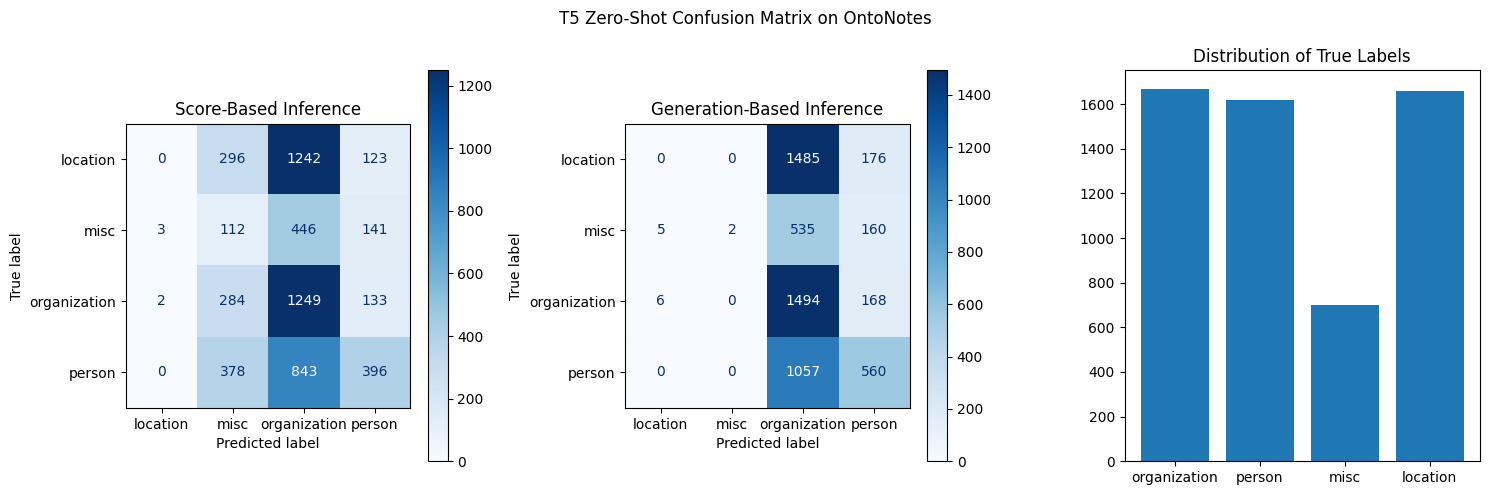

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
disp_score = ConfusionMatrixDisplay.from_predictions(
    true,
    predicted_score,
    cmap="Blues",
    ax=axes[0]
)
disp_score.ax_.set_title("Score-Based Inference")

disp_gen = ConfusionMatrixDisplay.from_predictions(
    true,
    predicted_gen,
    cmap="Blues",
    ax=axes[1]
)
disp_gen.ax_.set_title("Generation-Based Inference")

# Also plot the distribution of true labels.
label_counts = {}
for label in true:
    if label not in label_counts:
        label_counts[label] = 0
    label_counts[label] += 1
axes[2].bar(label_counts.keys(), label_counts.values())
axes[2].set_title("Distribution of True Labels")

plt.suptitle("T5 Zero-Shot Confusion Matrix on OntoNotes")
plt.tight_layout()
plt.show()

In [18]:
result2metrics(results_onto_score, onto_labels())

Precision: [('person', 0.49936948297604034), ('organization', 0.3304232804232804), ('misc', 0.10467289719626169), ('location', 0.0)]
Recall: [('organization', 0.7488009592326139), ('person', 0.24489795918367346), ('misc', 0.15954415954415954), ('location', 0.0)]
Macro Precision: 0.2336164151488956
Macro Recall: 0.28831076949011175
Micro Precision: 0.3110835694050991
Micro Recall: 0.3110835694050991
Macro F1: 0.22838960688490542
Micro F1: 0.3110835694050991


Compare to picking the most frequent label.

In [19]:
baseline_label = "organization"
baseline_results = []
for result in results_onto_score:
    baseline_results.append({
        "text": result["text"],
        "mention": result["mention"],
        "predicted_label": baseline_label,
        "true_labels": result["true_labels"]
    })
result2metrics(baseline_results, onto_labels())

Precision: [('organization', 0.2953257790368272), ('person', 0.0), ('location', 0.0), ('misc', 0.0)]
Recall: [('organization', 1.0), ('person', 0.0), ('location', 0.0), ('misc', 0.0)]
Macro Precision: 0.0738314447592068
Macro Recall: 0.25
Micro Precision: 0.2953257790368272
Micro Recall: 0.2953257790368272
Macro F1: 0.11399671951886278
Micro F1: 0.2953257790368272


##### Masking

In [20]:
if os.path.exists("results/T5/ontonotes/zero_shot/results_mention.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/ontonotes/zero_shot/results_mention.jsonl", "r") as f:
        results_onto_mention = [json.loads(line) for line in f]
else:
    results_onto_mention = run_inference(
        X_test_onto_mention, 
        label_space=onto_labels(),
        model=model,
        tokenizer=tokenizer,
        batch_size=128
    )

    with open("results/T5/ontonotes/zero_shot/results_mention.jsonl", "w") as f:
        for result in results_onto_mention:
            f.write(json.dumps(result) + "\n")
    
    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if os.path.exists("results/T5/ontonotes/zero_shot/results_context.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/ontonotes/zero_shot/results_context.jsonl", "r") as f:
        results_onto_context = [json.loads(line) for line in f]
else:
    results_onto_context = run_inference(
        X_test_onto_context, 
        label_space=onto_labels(),
        model=model,
        tokenizer=tokenizer,
        batch_size=128
    )

    with open("results/T5/ontonotes/zero_shot/results_context.jsonl", "w") as f:
        for result in results_onto_context:
            f.write(json.dumps(result) + "\n")
    
    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Loading results from disk.
Loading results from disk.


In [21]:
result2metrics(results_onto_mention, onto_labels())
print()
result2metrics(results_onto_context, onto_labels())

Precision: [('person', 0.3829479768786127), ('organization', 0.3012022780004219), ('misc', 0.06046511627906977), ('location', 0.0)]
Recall: [('organization', 0.8561151079136691), ('person', 0.16388373531230674), ('misc', 0.018518518518518517), ('location', 0.0)]
Macro Precision: 0.1861538427895261
Macro Recall: 0.25962934043612357
Micro Precision: 0.30205382436260625
Micro Recall: 0.30205382436260625
Macro F1: 0.1758783160418224
Micro F1: 0.30205382436260625

Precision: [('person', 0.6313131313131313), ('organization', 0.33543615401348703), ('misc', 0.10433763188745604), ('location', 0.0)]
Recall: [('organization', 0.9244604316546763), ('misc', 0.1267806267806268), ('person', 0.07730364873222016), ('location', 0.0)]
Macro Precision: 0.26777172930351856
Macro Recall: 0.2821361767918808
Micro Precision: 0.31090651558073656
Micro Recall: 0.31090651558073656
Macro F1: 0.18611726990439478
Micro F1: 0.31090651558073656


#### Fine-Tuning

In [22]:
if os.path.exists("results/T5/ontonotes/fine_tuned/model/model"):
    print("Loading model from disk.")
    trained_model_onto = T5ForConditionalGeneration.from_pretrained("results/T5/ontonotes/fine_tuned/model/model")
else:
    trained_model_onto = train_T5(
        model=model,
        tokenizer=tokenizer,
        X_train=X_train_onto,
        X_dev=X_dev_onto,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        learning_rate=3e-4,
        num_train_epochs=3,
        predict_with_generate=False,
        output_dir="results/T5/ontonotes/fine_tuned/model"
    )

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Loading model from disk.


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

#### Inference

In [23]:
if os.path.exists("results/T5/ontonotes/fine_tuned/results.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/ontonotes/fine_tuned/results.jsonl", "r") as f:
        trained_results_onto = [json.loads(line) for line in f]
else:
    trained_results_onto = run_inference(
        X_test_onto, 
        label_space=onto_labels(),
        model=trained_model_onto,
        tokenizer=tokenizer,
        batch_size=128
    )

    with open("results/T5/ontonotes/fine_tuned/results.jsonl", "w") as f:
        for result in trained_results_onto:
            f.write(json.dumps(result) + "\n")
    
    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Loading results from disk.


In [24]:
predicted = []
true = []

correct = []

for result in trained_results_onto:
    predicted.append(result["predicted_label"])
    true.append(result["true_labels"])

    if result["predicted_label"] == result["true_labels"]:
        correct.append(1)
    else:
        correct.append(0)

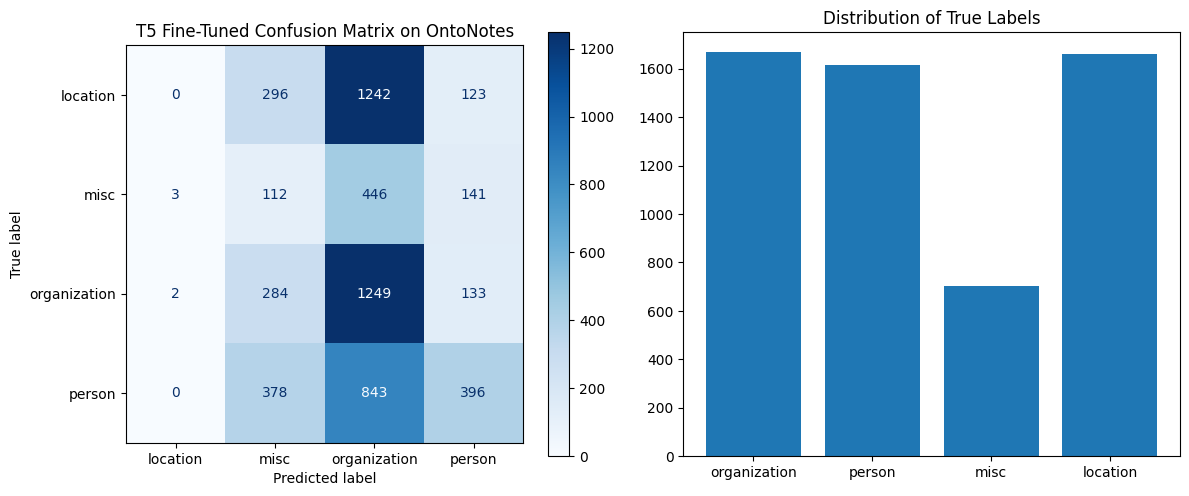

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
disp_score = ConfusionMatrixDisplay.from_predictions(
    true,
    predicted_score,
    cmap="Blues",
    ax=axes[0]
)
disp_score.ax_.set_title("T5 Fine-Tuned Confusion Matrix on OntoNotes")

# Also plot the distribution of true labels.
label_counts = {}
for label in true:
    if label not in label_counts:
        label_counts[label] = 0
    label_counts[label] += 1
axes[1].bar(label_counts.keys(), label_counts.values())
axes[1].set_title("Distribution of True Labels")

plt.tight_layout()
plt.show()

In [26]:
result2metrics(trained_results_onto, onto_labels())

Precision: [('person', 0.9923126201153107), ('organization', 0.9572031344183243), ('misc', 0.918918918918919), ('location', 0.9142028985507247)]
Recall: [('person', 0.9579468150896723), ('organization', 0.9520383693045563), ('location', 0.9494280553883203), ('misc', 0.9202279202279202)]
Macro Precision: 0.9456593930008197
Macro Recall: 0.9449102900026173
Micro Precision: 0.9490084985835694
Micro Recall: 0.9490084985835694
Macro F1: 0.9451240575954524
Micro F1: 0.9490084985835694


In [27]:
printed = 0
for result in trained_results_onto:
    if result["predicted_label"] != result["true_labels"]:
        print("Not Correct")
        print("Text:", result["text"])
        print("Mention:", result["mention"])
        print("True Labels:", result["true_labels"])
        print("Predicted Label:", result["predicted_label"])
        print()

        printed += 1
        if printed >= 5:
            break

Not Correct
Text: SOCCER - JAPAN GET LUCKY WIN , CHINA IN SURPRISE DEFEAT .
Mention: CHINA
True Labels: person
Predicted Label: organization

Not Correct
Text: Defender Hassan Abbas rose to intercept a long ball into the area in the 84th minute but only managed to divert it into the top corner of Bitar 's goal .
Mention: Bitar
True Labels: person
Predicted Label: location

Not Correct
Text: Bitar pulled off fine saves whenever they did .
Mention: Bitar
True Labels: person
Predicted Label: location

Not Correct
Text: Defender Hassan Abbas rose to intercept a long ball into the area in the 84th minute but only managed to divert it into the top corner of Bitar 's goal .
Mention: Bitar
True Labels: person
Predicted Label: location

Not Correct
Text: Japan : 19 - Kenichi Shimokawa , 2 - Hiroshige Yanagimoto , 3 - Naoki Soma , 4 - Masami Ihara , 5 - Norio Omura , 6 - Motohiro Yamaguchi , 8 - Masakiyo Maezono ( 7 - Yasuto Honda 71 ) , 9 - Takuya Takagi , 10 - Hiroshi Nanami , 11 - Kazuyoshi M

#### Masking

In [28]:
if os.path.exists("results/T5/ontonotes/fine_tuned/results_mention.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/ontonotes/fine_tuned/results_mention.jsonl", "r") as f:
        trained_results_onto_mention = [json.loads(line) for line in f]
else:
    trained_results_onto_mention = run_inference(
        X_test_onto_mention, 
        label_space=onto_labels(),
        model=trained_model_onto,
        tokenizer=tokenizer,
        batch_size=128
    )

    with open("results/T5/ontonotes/fine_tuned/results_mention.jsonl", "w") as f:
        for result in trained_results_onto_mention:
            f.write(json.dumps(result) + "\n")
    
    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if os.path.exists("results/T5/ontonotes/fine_tuned/results_context.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/ontonotes/fine_tuned/results_context.jsonl", "r") as f:
        trained_results_onto_context = [json.loads(line) for line in f]
else:
    trained_results_onto_context = run_inference(
        X_test_onto_context, 
        label_space=onto_labels(),
        model=trained_model_onto,
        tokenizer=tokenizer,
        batch_size=128
    )

    with open("results/T5/ontonotes/fine_tuned/results_context.jsonl", "w") as f:
        for result in trained_results_onto_context:
            f.write(json.dumps(result) + "\n")
    
    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Loading results from disk.
Loading results from disk.


In [29]:
result2metrics(trained_results_onto_mention, onto_labels())
print()
result2metrics(trained_results_onto_context, onto_labels())

Precision: [('location', 0.5734480639213276), ('person', 0.5558823529411765), ('organization', 0.5392354124748491), ('misc', 0.20287539936102236)]
Recall: [('misc', 0.7236467236467237), ('location', 0.5617098133654425), ('person', 0.35064935064935066), ('organization', 0.1606714628297362)]
Macro Precision: 0.46786030717459387
Macro Recall: 0.44916933762281325
Micro Precision: 0.40297450424929177
Micro Recall: 0.40297450424929177
Macro F1: 0.3905083093066737
Micro F1: 0.40297450424929177

Precision: [('person', 0.9583333333333334), ('misc', 0.8846715328467153), ('location', 0.7385826771653543), ('organization', 0.6508135168961201)]
Recall: [('organization', 0.935251798561151), ('misc', 0.8632478632478633), ('person', 0.7680890538033395), ('location', 0.5647200481637568)]
Macro Precision: 0.8081002650603808
Macro Recall: 0.7828271909440276
Micro Precision: 0.7694759206798867
Micro Recall: 0.7694759206798867
Macro F1: 0.7835349539996032
Micro F1: 0.7694759206798866


In [30]:
printed_change = 0
printed_no_change = 0

for res1, res2 in zip(trained_results_onto, trained_results_onto_mention):
    if (
        res1["predicted_label"] == res1["true_labels"] 
        and res2["predicted_label"] == res2["true_labels"] 
        and printed_no_change < 5
    ):
        print("Text:", res1["text"])
        print("Mention:", res1["mention"])
        print("True Labels:", res1["true_labels"])
        print("Predicted Label without Masking:", res1["predicted_label"])
        print("Predicted Label with Masking:", res2["predicted_label"])
        print()
        printed_no_change += 1
    elif (
        res1["predicted_label"] == res1["true_labels"]
        and res2["predicted_label"] != res2["true_labels"] 
        and printed_change < 5
    ):
        print("Text:", res1["text"])
        print("Mention:", res1["mention"])
        print("True Labels:", res1["true_labels"])
        print("Predicted Label without Masking:", res1["predicted_label"])
        print("Predicted Label with Masking:", res2["predicted_label"])
        print()
        printed_change += 1
    if printed_change >= 5 and printed_no_change >= 5:
        break

Text: SOCCER - JAPAN GET LUCKY WIN , CHINA IN SURPRISE DEFEAT .
Mention: JAPAN
True Labels: organization
Predicted Label without Masking: organization
Predicted Label with Masking: organization

Text: Nadim Ladki
Mention: Nadim Ladki
True Labels: person
Predicted Label without Masking: person
Predicted Label with Masking: misc

Text: AL-AIN , United Arab Emirates 1996-12-06
Mention: AL-AIN
True Labels: organization
Predicted Label without Masking: organization
Predicted Label with Masking: location

Text: AL-AIN , United Arab Emirates 1996-12-06
Mention: United Arab Emirates
True Labels: organization
Predicted Label without Masking: organization
Predicted Label with Masking: organization

Text: Japan began the defence of their Asian Cup title with a lucky 2-1 win against Syria in a Group C championship match on Friday .
Mention: Japan
True Labels: organization
Predicted Label without Masking: organization
Predicted Label with Masking: misc

Text: Japan began the defence of their Asian 

In [31]:
printed_change = 0
printed_no_change = 0

for res1, res2 in zip(trained_results_onto, trained_results_onto_context):
    if (
        res1["predicted_label"] == res1["true_labels"] 
        and res2["predicted_label"] == res2["true_labels"] 
        and printed_no_change < 5
    ):
        print("Text:", res1["text"])
        print("Mention:", res1["mention"])
        print("True Labels:", res1["true_labels"])
        print("Predicted Label without Masking:", res1["predicted_label"])
        print("Predicted Label with Masking:", res2["predicted_label"])
        print()
        printed_no_change += 1
    elif (
        res1["predicted_label"] == res1["true_labels"]
        and res2["predicted_label"] != res2["true_labels"] 
        and printed_change < 5
    ):
        print("Text:", res1["text"])
        print("Mention:", res1["mention"])
        print("True Labels:", res1["true_labels"])
        print("Predicted Label without Masking:", res1["predicted_label"])
        print("Predicted Label with Masking:", res2["predicted_label"])
        print()
        printed_change += 1
    if printed_change >= 5 and printed_no_change >= 5:
        break

Text: SOCCER - JAPAN GET LUCKY WIN , CHINA IN SURPRISE DEFEAT .
Mention: JAPAN
True Labels: organization
Predicted Label without Masking: organization
Predicted Label with Masking: organization

Text: Nadim Ladki
Mention: Nadim Ladki
True Labels: person
Predicted Label without Masking: person
Predicted Label with Masking: person

Text: AL-AIN , United Arab Emirates 1996-12-06
Mention: AL-AIN
True Labels: organization
Predicted Label without Masking: organization
Predicted Label with Masking: location

Text: AL-AIN , United Arab Emirates 1996-12-06
Mention: United Arab Emirates
True Labels: organization
Predicted Label without Masking: organization
Predicted Label with Masking: organization

Text: Japan began the defence of their Asian Cup title with a lucky 2-1 win against Syria in a Group C championship match on Friday .
Mention: Japan
True Labels: organization
Predicted Label without Masking: organization
Predicted Label with Masking: organization

Text: Japan began the defence of th

---
### FIGER

In [32]:
# Renew model.
del trained_model_onto
del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

model = T5ForConditionalGeneration.from_pretrained("google-t5/t5-base")
tokenizer = AutoTokenizer.from_pretrained("google-t5/t5-base", use_fast=True)

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

In [33]:
label_tree = figer_labels()
label_list = figer_labels_list()

only_fine_figer_labels = []
for label in label_list:
    if len(label) == 1:
        only_fine_figer_labels.append(label[0])
    else:
        only_fine_figer_labels.append(label[1])

Processing mapping file: 0it [00:00, ?it/s]

Processing mapping file: 0it [00:00, ?it/s]

In [34]:
print(len(only_fine_figer_labels))

113


#### Zero-Shot Inference

In [35]:
if os.path.exists("results/T5/figer/zero_shot/results.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/figer/zero_shot/results.jsonl", "r") as f:
        results_figer = [json.loads(line) for line in f]
else:
    results_figer = run_inference_with_generation(
        X_test_figer, 
        label_space=only_fine_figer_labels,
        model=model,
        tokenizer=tokenizer,
        batch_size=45,
        num_beams=5,
        max_labels=8
    )

    with open("results/T5/figer/zero_shot/results.jsonl", "w") as f:
        for result in results_figer:
            f.write(json.dumps(result) + "\n")

    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Loading results from disk.


In [36]:
for i in range(10):
    print("Text:", results_figer[i]["text"])
    print("Mention:", results_figer[i]["mention"])
    print("True Labels:", results_figer[i]["true_labels"])
    print("Predicted Labels:", results_figer[i]["predicted_label"])
    print()

Text: He was the ninth child and sixth son of George III and Charlotte of Mecklenburg-Strelitz .
Mention: Charlotte of Mecklenburg-Strelitz
True Labels: [['person']]
Predicted Labels: ['company', 'person', 'organization']

Text: The album features production from Terrace Martin , DJ Quik , Pete Rock , Lil Jon are among producers working on the album .
Mention: Pete Rock
True Labels: [['person'], ['person', 'artist']]
Predicted Labels: ['music']

Text: E. blohmi is distributed in the Orinoco River basin and Tuy River of the Caribbean coast of Venezuela .
Mention: Tuy River
True Labels: [['location', 'body of water'], ['location']]
Predicted Labels: ['country', 'city', 'county']

Text: Stephen Beckett ( born Stephen Jenkins on 24 May 1967 ) is an English actor , known for portraying Dr Matt Ramsden in Coronation Street and Mike Jarvis in The Bill .
Mention: Coronation Street
True Labels: [['broadcast program']]
Predicted Labels: ['actor', 'director']

Text: A native of Bradenville , Penn

In [37]:
for i, result in enumerate(results_figer):
    simple_true_labels = []
    for label in result["true_labels"]:
        if len(label) == 1:
            simple_true_labels.append(label[0])
        else:
            simple_true_labels.append(label[1])
    result["true_labels"] = simple_true_labels

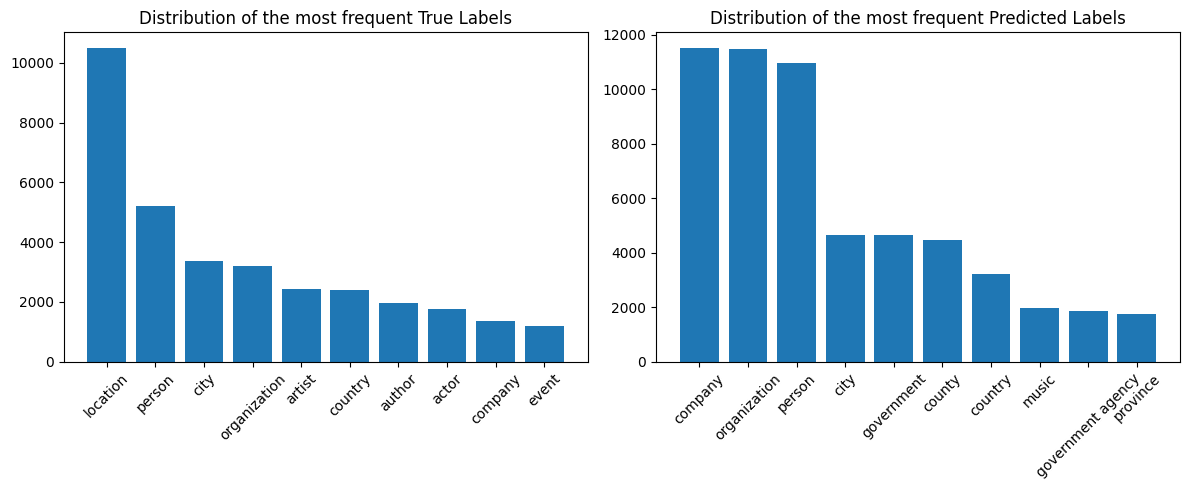

In [38]:
dist_predicted = {}
dist_true = {}

for result in results_figer:
    for label in result["predicted_label"]:
        if label not in dist_predicted:
            dist_predicted[label] = 0
        dist_predicted[label] += 1
    for label in result["true_labels"]:
        if label not in dist_true:
            dist_true[label] = 0
        dist_true[label] += 1

dist_predicted = sorted(dist_predicted.items(), key=lambda x: x[1], reverse=True)[:10]
dist_true = sorted(dist_true.items(), key=lambda x: x[1], reverse=True)[:10]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar([x[0] for x in dist_true], [x[1] for x in dist_true])
axes[0].set_title("Distribution of the most frequent True Labels")
axes[0].tick_params(axis='x', rotation=45)
axes[1].bar([x[0] for x in dist_predicted], [x[1] for x in dist_predicted])
axes[1].set_title("Distribution of the most frequent Predicted Labels")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [39]:
result2metrics(results_figer, only_fine_figer_labels)

Precision: [('award', 1.0), ('living thing', 0.7111111111111111), ('athlete', 0.6666666666666666), ('election', 0.6), ('medical treatment', 0.5714285714285714), ('disease', 0.5306122448979592), ('event', 0.5042016806722689), ('military conflict', 0.5), ('transit', 0.5), ('broadcast network', 0.475), ('artist', 0.47478991596638653), ('actor', 0.45596868884540115), ('building', 0.45454545454545453), ('stock exchange', 0.4444444444444444), ('doctor', 0.42857142857142855), ('educational institution', 0.41732283464566927), ('ethnicity', 0.40285714285714286), ('play', 0.4), ('sports facility', 0.375), ('author', 0.37037037037037035), ('weapon', 0.36363636363636365), ('island', 0.3508771929824561), ('programming language', 0.3448275862068966), ('road', 0.34146341463414637), ('terrorist attack', 0.3333333333333333), ('symptom', 0.3125), ('mountain', 0.3116883116883117), ('drug', 0.3055555555555556), ('country', 0.3049007444168734), ('city', 0.2947617003005582), ('sports league', 0.287128712871

In [40]:
num_pos = 0
num_neg = 0

for result in results_figer:
    for label in result["predicted_label"]:
        if label in result["true_labels"]:
            num_pos += 1
        else:
            num_neg += 1

print("Number of positive predictions:", num_pos)
print("Number of negative predictions:", num_neg)

Number of positive predictions: 11636
Number of negative predictions: 65679


In [41]:
num_pos_results = 0

for result in results_figer:
    for label in result["predicted_label"]:
        if label in result["true_labels"]:
            num_pos_results += 1
            break

print("Number of samples with at least one correct prediction:", num_pos_results, "(", (num_pos_results / len(results_figer)) * 100, "% )")

Number of samples with at least one correct prediction: 10252 ( 41.008 % )


In [42]:
# Most frequent 3 labels as baseline.
baseline_labels = [x[0] for x in dist_true][:3]
baseline_results = []

for result in results_figer:
    baseline_results.append({
        "text": result["text"],
        "mention": result["mention"],
        "predicted_label": baseline_labels,
        "true_labels": result["true_labels"]
    })

result2metrics(baseline_results, only_fine_figer_labels)

Precision: [('location', 0.41988), ('person', 0.20824), ('city', 0.1352), ('art', 0.0), ('film', 0.0), ('astral body', 0.0), ('award', 0.0), ('biology', 0.0), ('body part', 0.0), ('tv channel', 0.0), ('broadcast network', 0.0), ('broadcast program', 0.0), ('building', 0.0), ('airport', 0.0), ('dam', 0.0), ('hospital', 0.0), ('hotel', 0.0), ('library', 0.0), ('power station', 0.0), ('restaurant', 0.0), ('sports facility', 0.0), ('theater', 0.0), ('chemistry', 0.0), ('algorithm', 0.0), ('programming language', 0.0), ('disease', 0.0), ('department', 0.0), ('educational degree', 0.0), ('event', 0.0), ('attack', 0.0), ('election', 0.0), ('military conflict', 0.0), ('natural disaster', 0.0), ('protest', 0.0), ('sports event', 0.0), ('terrorist attack', 0.0), ('currency', 0.0), ('stock exchange', 0.0), ('food', 0.0), ('game', 0.0), ('glacier', 0.0), ('island', 0.0), ('mountain', 0.0), ('god', 0.0), ('government', 0.0), ('political party', 0.0), ('government agency', 0.0), ('website', 0.0), ('

#### Masking

In [43]:
if os.path.exists("results/T5/figer/zero_shot/results_mention.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/figer/zero_shot/results_mention.jsonl", "r") as f:
        results_figer_mention = [json.loads(line) for line in f]
else:
    results_figer_mention = run_inference_with_generation(
        X_test_figer_mention, 
        label_space=only_fine_figer_labels,
        model=model,
        tokenizer=tokenizer,
        batch_size=45,
        num_beams=5,
        max_labels=8
    )

    with open("results/T5/figer/zero_shot/results_mention.jsonl", "w") as f:
        for result in results_figer_mention:
            f.write(json.dumps(result) + "\n")

    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if os.path.exists("results/T5/figer/zero_shot/results_context.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/figer/zero_shot/results_context.jsonl", "r") as f:
        results_figer_context = [json.loads(line) for line in f]
else:
    results_figer_context = run_inference_with_generation(
        X_test_figer_context, 
        label_space=only_fine_figer_labels,
        model=model,
        tokenizer=tokenizer,
        batch_size=45,
        num_beams=5,
        max_labels=8
    )

    with open("results/T5/figer/zero_shot/results_context.jsonl", "w") as f:
        for result in results_figer_context:
            f.write(json.dumps(result) + "\n")

    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Loading results from disk.


Loading results from disk.


In [44]:
for i, result in enumerate(results_figer_mention):
    simple_true_labels = []
    for label in result["true_labels"]:
        if len(label) == 1:
            simple_true_labels.append(label[0])
        else:
            simple_true_labels.append(label[1])
    result["true_labels"] = simple_true_labels

for i, result in enumerate(results_figer_context):
    simple_true_labels = []
    for label in result["true_labels"]:
        if len(label) == 1:
            simple_true_labels.append(label[0])
        else:
            simple_true_labels.append(label[1])
    result["true_labels"] = simple_true_labels

In [45]:
result2metrics(results_figer_mention, only_fine_figer_labels)
print()
result2metrics(results_figer_context, only_fine_figer_labels)

Precision: [('athlete', 1.0), ('military conflict', 0.6666666666666666), ('dam', 0.5), ('instrument', 0.5), ('ethnicity', 0.4435483870967742), ('living thing', 0.34375), ('artist', 0.33550913838120106), ('disease', 0.3333333333333333), ('location', 0.29411764705882354), ('city', 0.2936170212765957), ('currency', 0.2857142857142857), ('god', 0.275), ('actor', 0.24841772151898733), ('mountain', 0.2222222222222222), ('person', 0.21029250956807), ('country', 0.19825708061002179), ('author', 0.19325153374233128), ('drug', 0.1875), ('military', 0.18065693430656934), ('language', 0.1717557251908397), ('sports league', 0.1590909090909091), ('hospital', 0.14285714285714285), ('symptom', 0.14285714285714285), ('programming language', 0.1388888888888889), ('organization', 0.13365264746407715), ('sports team', 0.12962962962962962), ('sports facility', 0.1111111111111111), ('musician', 0.1106612685560054), ('religion', 0.09917355371900827), ('island', 0.0967741935483871), ('political party', 0.0949

In [46]:
for i in range(10):
    print("Text:", results_figer[i]["text"])
    print("Mention:", results_figer[i]["mention"])
    print("True Labels:", results_figer[i]["true_labels"])
    print("Predicted Labels:", results_figer[i]["predicted_label"])
    print("Predicted Labels with Mention Masking:", results_figer_mention[i]["predicted_label"])
    print("Predicted Labels with Context Masking:", results_figer_context[i]["predicted_label"])
    print()

Text: He was the ninth child and sixth son of George III and Charlotte of Mecklenburg-Strelitz .
Mention: Charlotte of Mecklenburg-Strelitz
True Labels: ['person']
Predicted Labels: ['company', 'person', 'organization']
Predicted Labels with Mention Masking: ['company', 'person', 'organization', 'government', 'government agency', 'political party', 'news agency', 'newspaper']
Predicted Labels with Context Masking: ['city', 'county', 'province', 'country']

Text: The album features production from Terrace Martin , DJ Quik , Pete Rock , Lil Jon are among producers working on the album .
Mention: Pete Rock
True Labels: ['person', 'artist']
Predicted Labels: ['music']
Predicted Labels with Mention Masking: ['artist']
Predicted Labels with Context Masking: ['artist', 'musician', 'actor', 'director', 'author']

Text: E. blohmi is distributed in the Orinoco River basin and Tuy River of the Caribbean coast of Venezuela .
Mention: Tuy River
True Labels: ['body of water', 'location']
Predicted L

#### Zero-Shot Inference with given coarse labels

In [47]:
if os.path.exists("results/T5/figer/zero_shot/results_given_coarse.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/figer/zero_shot/results_given_coarse.jsonl", "r") as f:
        results_figer_given_coarse = [json.loads(line) for line in f]
else:
    results_figer_given_coarse = run_inference_with_generation(
        X_test_figer, 
        label_space=only_fine_figer_labels,
        model=model,
        tokenizer=tokenizer,
        batch_size=45,
        num_beams=5,
        max_labels=8,
        fjger=True
    )

    with open("results/T5/figer/zero_shot/results_given_coarse.jsonl", "w") as f:
        for result in results_figer_given_coarse:
            f.write(json.dumps(result) + "\n")

    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Loading results from disk.


In [48]:
for i in range(10):
    print("Without Coarse Labels:")
    print("Text:", results_figer[i]["text"])
    print("Mention:", results_figer[i]["mention"])
    print("True Labels:", results_figer[i]["true_labels"])
    print("Predicted Labels:", results_figer[i]["predicted_label"])
    print()
    print("With Coarse Labels:")
    print("Text:", results_figer_given_coarse[i]["text"])
    print("Mention:", results_figer_given_coarse[i]["mention"])
    print("True Labels:", results_figer_given_coarse[i]["true_labels"])
    print("Predicted Labels:", results_figer_given_coarse[i]["predicted_label"])
    print()

Without Coarse Labels:
Text: He was the ninth child and sixth son of George III and Charlotte of Mecklenburg-Strelitz .
Mention: Charlotte of Mecklenburg-Strelitz
True Labels: ['person']
Predicted Labels: ['company', 'person', 'organization']

With Coarse Labels:
Text: He was the ninth child and sixth son of George III and Charlotte of Mecklenburg-Strelitz .
Mention: Charlotte of Mecklenburg-Strelitz
True Labels: [['person']]
Predicted Labels: ['chemistry', 'biology', 'art', 'music', 'theater', 'film']

Without Coarse Labels:
Text: The album features production from Terrace Martin , DJ Quik , Pete Rock , Lil Jon are among producers working on the album .
Mention: Pete Rock
True Labels: ['person', 'artist']
Predicted Labels: ['music']

With Coarse Labels:
Text: The album features production from Terrace Martin , DJ Quik , Pete Rock , Lil Jon are among producers working on the album .
Mention: Pete Rock
True Labels: [['person'], ['person', 'artist']]
Predicted Labels: ['company']

Withou

#### Fine-Tuning

In [49]:
if os.path.exists("results/T5/figer/fine_tuned/model/model"):
    print("Loading model from disk.")
    trained_model_figer = T5ForConditionalGeneration.from_pretrained("results/T5/figer/fine_tuned/model/model")
else:
    trained_model_figer = train_T5(
        model=model,
        tokenizer=tokenizer,
        X_train=X_train_figer,
        X_dev=X_dev_figer,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=3e-4,
        num_train_epochs=2,
        predict_with_generate=False, # False for faster training. Could potentially improve results further.
        output_dir="results/T5/figer/fine_tuned/model"
    )

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Loading model from disk.


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

#### Inference

In [50]:
if os.path.exists("results/T5/figer/fine_tuned/results.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/figer/fine_tuned/results.jsonl", "r") as f:
        trained_results_figer = [json.loads(line) for line in f]
else:
    trained_results_figer = run_inference_with_generation(
        X_test_figer, 
        label_space=only_fine_figer_labels,
        model=trained_model_figer,
        tokenizer=tokenizer,
        batch_size=45,
        num_beams=5,
        max_labels=8
    )

    with open("results/T5/figer/fine_tuned/results.jsonl", "w") as f:
        for result in trained_results_figer:
            f.write(json.dumps(result) + "\n")

    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Loading results from disk.


In [51]:
for i, result in enumerate(trained_results_figer):
    simple_true_labels = []
    for label in result["true_labels"]:
        if len(label) == 1:
            simple_true_labels.append(label[0])
        else:
            simple_true_labels.append(label[1])
    result["true_labels"] = simple_true_labels

In [52]:
result2metrics(trained_results_figer, only_fine_figer_labels)

Precision: [('tv channel', 1.0), ('dam', 1.0), ('power station', 1.0), ('department', 1.0), ('terrorist attack', 1.0), ('currency', 1.0), ('stock exchange', 1.0), ('newspaper', 1.0), ('fraternity sorority', 1.0), ('camera', 1.0), ('train', 1.0), ('programming language', 0.975), ('news agency', 0.9707112970711297), ('sports league', 0.9663299663299664), ('election', 0.9655172413793104), ('educational degree', 0.9645390070921985), ('person', 0.9643268124280783), ('location', 0.9642924086223055), ('attack', 0.9615384615384616), ('living thing', 0.9615384615384616), ('astral body', 0.96), ('ship', 0.9594594594594594), ('law', 0.9574468085106383), ('province', 0.9574209245742092), ('weapon', 0.9545454545454546), ('political party', 0.9525862068965517), ('country', 0.9525354969574037), ('religion', 0.950920245398773), ('cemetery', 0.9502369668246445), ('language', 0.9488950276243094), ('county', 0.9476082004555809), ('road', 0.9458333333333333), ('disease', 0.9456521739130435), ('title', 0.9

#### Masking

In [53]:
if os.path.exists("results/T5/figer/fine_tuned/results_mention.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/figer/fine_tuned/results_mention.jsonl", "r") as f:
        trained_results_figer_mention = [json.loads(line) for line in f]
else:
    trained_results_figer_mention = run_inference_with_generation(
        X_test_figer_mention, 
        label_space=only_fine_figer_labels,
        model=trained_model_figer,
        tokenizer=tokenizer,
        batch_size=45,
        num_beams=5,
        max_labels=8
    )

    with open("results/T5/figer/fine_tuned/results_mention.jsonl", "w") as f:
        for result in trained_results_figer_mention:
            f.write(json.dumps(result) + "\n")

    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if os.path.exists("results/T5/figer/fine_tuned/results_context.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/figer/fine_tuned/results_context.jsonl", "r") as f:
        trained_results_figer_context = [json.loads(line) for line in f]
else:
    trained_results_figer_context = run_inference_with_generation(
        X_test_figer_context, 
        label_space=only_fine_figer_labels,
        model=trained_model_figer,
        tokenizer=tokenizer,
        batch_size=45,
        num_beams=5,
        max_labels=8
    )

    with open("results/T5/figer/fine_tuned/results_context.jsonl", "w") as f:
        for result in trained_results_figer_context:
            f.write(json.dumps(result) + "\n")

    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Loading results from disk.
Loading results from disk.


In [54]:
for i, result in enumerate(trained_results_figer_mention):
    simple_true_labels = []
    for label in result["true_labels"]:
        if len(label) == 1:
            simple_true_labels.append(label[0])
        else:
            simple_true_labels.append(label[1])
    result["true_labels"] = simple_true_labels

for i, result in enumerate(trained_results_figer_context):
    simple_true_labels = []
    for label in result["true_labels"]:
        if len(label) == 1:
            simple_true_labels.append(label[0])
        else:
            simple_true_labels.append(label[1])
    result["true_labels"] = simple_true_labels

In [55]:
result2metrics(trained_results_figer_mention, only_fine_figer_labels)
print()
result2metrics(trained_results_figer_context, only_fine_figer_labels)

Precision: [('fraternity sorority', 1.0), ('camera', 1.0), ('location', 0.8014727540500737), ('living thing', 0.7396061269146609), ('chemistry', 0.7023809523809523), ('athlete', 0.6932907348242812), ('person', 0.6876955161626694), ('train', 0.6666666666666666), ('software', 0.6496350364963503), ('weapon', 0.6470588235294118), ('food', 0.6440677966101694), ('car', 0.6363636363636364), ('computer', 0.6), ('game', 0.5670103092783505), ('website', 0.55), ('film', 0.549636803874092), ('programming language', 0.5490196078431373), ('sports team', 0.541795665634675), ('music', 0.5395833333333333), ('province', 0.5269709543568465), ('law', 0.5185185185185185), ('god', 0.5), ('architect', 0.5), ('railway', 0.5), ('musician', 0.48693586698337293), ('organization', 0.4858361254949741), ('military', 0.48344370860927155), ('artist', 0.48338762214983716), ('instrument', 0.48148148148148145), ('airplane', 0.47560975609756095), ('time', 0.46153846153846156), ('ship', 0.45132743362831856), ('educational

In [56]:
for i in range(10):
    print("Text:", trained_results_figer[i]["text"])
    print("Mention:", trained_results_figer[i]["mention"])
    print("True Labels:", trained_results_figer[i]["true_labels"])
    print("Predicted Labels:", trained_results_figer[i]["predicted_label"])
    print("Predicted Labels with Mention Masking:", trained_results_figer_mention[i]["predicted_label"])
    print("Predicted Labels with Context Masking:", trained_results_figer_context[i]["predicted_label"])
    print()

Text: He was the ninth child and sixth son of George III and Charlotte of Mecklenburg-Strelitz .
Mention: Charlotte of Mecklenburg-Strelitz
True Labels: ['person']
Predicted Labels: ['person']
Predicted Labels with Mention Masking: ['monarch', 'person', 'politician']
Predicted Labels with Context Masking: ['person']

Text: The album features production from Terrace Martin , DJ Quik , Pete Rock , Lil Jon are among producers working on the album .
Mention: Pete Rock
True Labels: ['person', 'artist']
Predicted Labels: ['artist', 'person']
Predicted Labels with Mention Masking: ['music']
Predicted Labels with Context Masking: ['actor', 'artist', 'person']

Text: E. blohmi is distributed in the Orinoco River basin and Tuy River of the Caribbean coast of Venezuela .
Mention: Tuy River
True Labels: ['body of water', 'location']
Predicted Labels: ['body of water', 'location']
Predicted Labels with Mention Masking: ['location']
Predicted Labels with Context Masking: ['body of water', 'location'

#### Generalization to OntoNotes

In [57]:
if os.path.exists("results/T5/figer/fine_tuned/results_onto.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/figer/fine_tuned/results_onto.jsonl", "r") as f:
        onto_results_figer = [json.loads(line) for line in f]
else:
    onto_results_figer = run_inference_with_generation(
        X_test_onto, 
        label_space=onto_labels(),
        model=trained_model_figer,
        tokenizer=tokenizer,
        batch_size=45,
        num_beams=5,
        max_labels=1
    )

    with open("results/T5/figer/fine_tuned/results_onto.jsonl", "w") as f:
        for result in onto_results_figer:
            f.write(json.dumps(result) + "\n")

    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Loading results from disk.


In [58]:
result2metrics(onto_results_figer, onto_labels())

Precision: [('person', 0.8408186469584992), ('organization', 0.33695652173913043), ('location', 0.3323431117712588), ('misc', 0.0)]
Recall: [('person', 0.9146567717996289), ('location', 0.5388320288982541), ('organization', 0.24160671462829736), ('misc', 0.0)]
Macro Precision: 0.3775295701172221
Macro Recall: 0.4237738788315451
Micro Precision: 0.49167847025495753
Micro Recall: 0.49167847025495753
Macro F1: 0.39218140752588626
Micro F1: 0.49167847025495753


In [59]:
for i in range(5):
    print("Text:", onto_results_figer[i]["text"])
    print("Mention:", onto_results_figer[i]["mention"])
    print("True Labels:", onto_results_figer[i]["true_labels"])
    print("Predicted Labels:", onto_results_figer[i]["predicted_label"])
    print()

Text: SOCCER - JAPAN GET LUCKY WIN , CHINA IN SURPRISE DEFEAT .
Mention: JAPAN
True Labels: organization
Predicted Labels: ['location']

Text: SOCCER - JAPAN GET LUCKY WIN , CHINA IN SURPRISE DEFEAT .
Mention: CHINA
True Labels: person
Predicted Labels: ['location']

Text: Nadim Ladki
Mention: Nadim Ladki
True Labels: person
Predicted Labels: ['person']

Text: AL-AIN , United Arab Emirates 1996-12-06
Mention: AL-AIN
True Labels: organization
Predicted Labels: ['location']

Text: AL-AIN , United Arab Emirates 1996-12-06
Mention: United Arab Emirates
True Labels: organization
Predicted Labels: ['location']



#### Ultra-Fine Entity Typing

In [60]:
# Renew model.
del trained_model_figer
del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

model = T5ForConditionalGeneration.from_pretrained("google-t5/t5-base")
tokenizer = AutoTokenizer.from_pretrained("google-t5/t5-base", use_fast=True)

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

##### Zero-Shot Inference

In [61]:
if os.path.exists("results/T5/ultra_fine/zero_shot/results.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/ultra_fine/zero_shot/results.jsonl", "r") as f:
        results_ultra = [json.loads(line) for line in f]
else:
    results_ultra = run_inference_with_generation(
        X_test_ultra, 
        label_space=ultra_labels(),
        model=model,
        tokenizer=tokenizer,
        batch_size=45,
        num_beams=5,
        max_labels=8
    )

    with open("results/T5/ultra_fine/zero_shot/results.jsonl", "w") as f:
        for result in results_ultra:
            f.write(json.dumps(result) + "\n")

    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Running inference on cuda.
Building label trie.
Tokenizing prompts.


Generating:   0%|          | 0/45 [00:00<?, ?it/s]

In [62]:
result2metrics(results_ultra, ultra_labels())

Precision: [('time', 1.0), ('car', 1.0), ('conflict', 1.0), ('drug', 1.0), ('film', 1.0), ('hotel', 1.0), ('planet', 1.0), ('product', 1.0), ('ship', 1.0), ('aircraft', 1.0), ('baby', 1.0), ('band', 1.0), ('bomb', 1.0), ('businessman', 1.0), ('cartoon', 1.0), ('casino', 1.0), ('contact', 1.0), ('data', 1.0), ('flag', 1.0), ('free agent', 1.0), ('golf course', 1.0), ('golfer', 1.0), ('goods', 1.0), ('hip', 1.0), ('hockey', 1.0), ('isle', 1.0), ('landslide', 1.0), ('magazine', 1.0), ('model', 1.0), ('money', 1.0), ('part', 1.0), ('party', 1.0), ('president', 1.0), ('prime minister', 1.0), ('promotion', 1.0), ('public transport', 1.0), ('race', 1.0), ('report', 1.0), ('set', 1.0), ('stadium', 1.0), ('step', 1.0), ('storm', 1.0), ('union', 1.0), ('user', 1.0), ('verse', 1.0), ('vessel', 1.0), ('war', 1.0), ('year', 1.0), ('amnesty', 1.0), ('blanket', 1.0), ('diesel', 1.0), ('poverty line', 1.0), ('royalty', 1.0), ('sport', 0.6666666666666666), ('hurricane', 0.6666666666666666), ('actor', 0

In [63]:
for i in range(5):
    print("Text:", results_ultra[i]["text"])
    print("Mention:", results_ultra[i]["mention"])
    print("True Labels:", results_ultra[i]["true_labels"])
    print("Predicted Labels:", results_ultra[i]["predicted_label"])
    print()

Text: On late Monday night , 30th Nov 2009 , Bangladesh Police arrested Rajkhowa somewhere near Dhaka .
Mention: late Monday night
True Labels: ['day', 'time', 'weekday', 'date']
Predicted Labels: ['police']

Text: Leo W. Gerard , president of the steelworkers union , said he and several leaders of the AFL-CIO had organized joint events this week with the Sierra Club and the Alliance for Climate Protection .
Mention: joint events
True Labels: ['confluence', 'gathering', 'conference', 'meeting', 'event', 'ceremony']
Predicted Labels: ['symphony', 'symphony orchestra']

Text: Peace agreements will only bring further losses and push back our cause , " he added , pointing out that Abbas 's Fatah party also maintains its own armed wing , the loosely affiliated Al - Aqsa Martyrs Brigades .
Mention: he
True Labels: ['spokesman', 'statesman', 'policeman', 'spokesperson', 'politician', 'serviceman', 'person', 'official']
Predicted Labels: ['meanwhile']

Text: He was re-elected in the 1887 gener

In [64]:
test_label_space = set()
for result in results_ultra:
    for label in result["true_labels"]:
        test_label_space.add(label)

test_label_space = list(test_label_space)
print("Number of unique labels in the test set:", len(test_label_space))

Number of unique labels in the test set: 1682


In [65]:
if os.path.exists("results/T5/ultra_fine/zero_shot/results_limited.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/ultra_fine/zero_shot/results_limited.jsonl", "r") as f:
        results_ultra_limited = [json.loads(line) for line in f]
else:
    results_ultra_limited = run_inference_with_generation(
        X_test_ultra, 
        label_space=test_label_space,
        model=model,
        tokenizer=tokenizer,
        batch_size=45,
        num_beams=5,
        max_labels=8
    )

    with open("results/T5/ultra_fine/zero_shot/results_limited.jsonl", "w") as f:
        for result in results_ultra_limited:
            f.write(json.dumps(result) + "\n")

    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Running inference on cuda.
Building label trie.
Tokenizing prompts.


Generating:   0%|          | 0/45 [00:00<?, ?it/s]

In [66]:
for result in results_ultra_limited:
    true_labels = []
    for label in result["true_labels"]:
        true_labels = []
        if label in test_label_space:
            true_labels.append(label)
    result["true_labels"] = true_labels

In [67]:
result2metrics(results_ultra_limited, test_label_space)

Precision: [('contact', 1.0), ('pregnancy', 1.0), ('battle', 1.0), ('anniversary', 1.0), ('part', 1.0), ('monkey', 1.0), ('food', 1.0), ('diesel', 1.0), ('secret police', 1.0), ('infant', 0.5), ('railway', 0.5), ('flood', 0.5), ('ship', 0.5), ('union', 0.5), ('borough', 0.5), ('woman', 0.5), ('professional', 0.5), ('cyclone', 0.2857142857142857), ('land', 0.16666666666666666), ('company', 0.125), ('news', 0.125), ('government', 0.09090909090909091), ('terrorism', 0.08333333333333333), ('petroleum', 0.05555555555555555), ('family', 0.030303030303030304), ('adult', 0.026717557251908396), ('typhoon', 0.025), ('male', 0.020224719101123594), ('female', 0.006726457399103139), ('era', 0.0), ('state', 0.0), ('advancement', 0.0), ('participant', 0.0), ('bomb', 0.0), ('opposition', 0.0), ('domain', 0.0), ('liquid', 0.0), ('confirmation', 0.0), ('passport', 0.0), ('spokesman', 0.0), ('purpose', 0.0), ('mishap', 0.0), ('collaboration', 0.0), ('passing', 0.0), ('covering', 0.0), ('tradition', 0.0),

In [69]:
for i in range(5):
    print("Text:", results_ultra_limited[i]["text"])
    print("Mention:", results_ultra_limited[i]["mention"])
    print("True Labels:", results_ultra_limited[i]["true_labels"])
    print("Predicted Labels:", results_ultra_limited[i]["predicted_label"])
    print()

Text: On late Monday night , 30th Nov 2009 , Bangladesh Police arrested Rajkhowa somewhere near Dhaka .
Mention: late Monday night
True Labels: ['date']
Predicted Labels: ['police']

Text: Leo W. Gerard , president of the steelworkers union , said he and several leaders of the AFL-CIO had organized joint events this week with the Sierra Club and the Alliance for Climate Protection .
Mention: joint events
True Labels: ['ceremony']
Predicted Labels: ['symphony', 'symphony orchestra']

Text: Peace agreements will only bring further losses and push back our cause , " he added , pointing out that Abbas 's Fatah party also maintains its own armed wing , the loosely affiliated Al - Aqsa Martyrs Brigades .
Mention: he
True Labels: ['official']
Predicted Labels: ['adolescent', 'young', 'male', 'female']

Text: He was re-elected in the 1887 general election and represented Kaiapoi until the 1890 election , when he retired from the lower house .
Mention: the lower house
True Labels: ['legislature

##### Masking

In [70]:
if os.path.exists("results/T5/ultra_fine/zero_shot/results_mention.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/ultra_fine/zero_shot/results_mention.jsonl", "r") as f:
        results_ultra_mention = [json.loads(line) for line in f]
else:
    results_ultra_mention = run_inference_with_generation(
        X_test_ultra_mention, 
        label_space=ultra_labels(),
        model=model,
        tokenizer=tokenizer,
        batch_size=45,
        num_beams=5,
        max_labels=8
    )

    with open("results/T5/ultra_fine/zero_shot/results_mention.jsonl", "w") as f:
        for result in results_ultra_mention:
            f.write(json.dumps(result) + "\n")

    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if os.path.exists("results/T5/ultra_fine/zero_shot/results_context.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/ultra_fine/zero_shot/results_context.jsonl", "r") as f:
        results_ultra_context = [json.loads(line) for line in f]
else:
    results_ultra_context = run_inference_with_generation(
        X_test_ultra_context, 
        label_space=ultra_labels(),
        model=model,
        tokenizer=tokenizer,
        batch_size=45,
        num_beams=5,
        max_labels=8
    )

    with open("results/T5/ultra_fine/zero_shot/results_context.jsonl", "w") as f:
        for result in results_ultra_context:
            f.write(json.dumps(result) + "\n")

    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Running inference on cuda.
Building label trie.
Tokenizing prompts.


Generating:   0%|          | 0/45 [00:00<?, ?it/s]

Running inference on cuda.
Building label trie.
Tokenizing prompts.


Generating:   0%|          | 0/45 [00:00<?, ?it/s]

In [71]:
result2metrics(results_ultra_mention, ultra_labels())
print()
result2metrics(results_ultra_context, ultra_labels())

Precision: [('ship', 1.0), ('church', 1.0), ('monkey', 1.0), ('philosopher', 1.0), ('stadium', 1.0), ('storm', 1.0), ('table', 1.0), ('user', 1.0), ('vessel', 1.0), ('desk', 1.0), ('embassy', 1.0), ('cyclone', 0.75), ('hurricane', 0.75), ('person', 0.6666666666666666), ('police', 0.6666666666666666), ('fish', 0.5), ('insurance company', 0.5), ('union', 0.5), ('waste', 0.5), ('military', 0.3333333333333333), ('association', 0.3333333333333333), ('organization', 0.25), ('emperor', 0.25), ('petroleum', 0.25), ('school', 0.25), ('wind', 0.25), ('woman', 0.2), ('government', 0.16), ('team', 0.14285714285714285), ('company', 0.11764705882352941), ('oil', 0.1111111111111111), ('smuggling', 0.1111111111111111), ('teacher', 0.1), ('male', 0.09655172413793103), ('adult', 0.07903780068728522), ('typhoon', 0.07692307692307693), ('land', 0.06666666666666667), ('gas', 0.05555555555555555), ('business', 0.04081632653061224), ('female', 0.03793103448275862), ('child', 0.011363636363636364), ('sand', 0

In [72]:
for i in range(10):
    print("Text:", results_ultra[i]["text"])
    print("Mention:", results_ultra[i]["mention"])
    print("True Labels:", results_ultra[i]["true_labels"])
    print("Predicted Labels:", results_ultra[i]["predicted_label"])
    print("Predicted Labels with Mention Masking:", results_ultra_mention[i]["predicted_label"])
    print("Predicted Labels with Context Masking:", results_ultra_context[i]["predicted_label"])
    print()

Text: On late Monday night , 30th Nov 2009 , Bangladesh Police arrested Rajkhowa somewhere near Dhaka .
Mention: late Monday night
True Labels: ['day', 'time', 'weekday', 'date']
Predicted Labels: ['police']
Predicted Labels with Mention Masking: ['public', 'private']
Predicted Labels with Context Masking: ['symphony', 'symphony orchestra']

Text: Leo W. Gerard , president of the steelworkers union , said he and several leaders of the AFL-CIO had organized joint events this week with the Sierra Club and the Alliance for Climate Protection .
Mention: joint events
True Labels: ['confluence', 'gathering', 'conference', 'meeting', 'event', 'ceremony']
Predicted Labels: ['symphony', 'symphony orchestra']
Predicted Labels with Mention Masking: ['adolescent', 'adult', 'male', 'female']
Predicted Labels with Context Masking: ['symphony', 'symphony orchestra', 'adolescent']

Text: Peace agreements will only bring further losses and push back our cause , " he added , pointing out that Abbas 's F

##### Fine-Tuning

In [73]:
if os.path.exists("results/T5/ultra_fine/fine_tuned/model/model"):
    print("Loading model from disk.")
    trained_model_ultra = T5ForConditionalGeneration.from_pretrained("results/T5/ultra_fine/fine_tuned/model/model")
else:
    trained_model_ultra = train_T5(
        model=model,
        tokenizer=tokenizer,
        X_train=X_train_ultra,
        X_dev=X_dev_ultra,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=3e-4,
        num_train_epochs=2,
        predict_with_generate=False, # False for faster training. Could potentially improve results further.
        output_dir="results/T5/ultra_fine/fine_tuned/model"
    )

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Loading model from disk.


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

##### Inference

In [74]:
if os.path.exists("results/T5/ultra_fine/fine_tuned/results.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/ultra_fine/fine_tuned/results.jsonl", "r") as f:
        trained_results_ultra = [json.loads(line) for line in f]
else:
    trained_results_ultra = run_inference_with_generation(
        X_test_ultra, 
        label_space=ultra_labels(),
        model=trained_model_ultra,
        tokenizer=tokenizer,
        batch_size=45,
        num_beams=5,
        max_labels=8
    )

    with open("results/T5/ultra_fine/fine_tuned/results.jsonl", "w") as f:
        for result in trained_results_ultra:
            f.write(json.dumps(result) + "\n")

    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Running inference on cuda.
Building label trie.
Tokenizing prompts.


Generating:   0%|          | 0/45 [00:00<?, ?it/s]

In [75]:
result2metrics(trained_results_ultra, ultra_labels())

Precision: [('object', 1.0), ('airline', 1.0), ('bridge', 1.0), ('currency', 1.0), ('drug', 1.0), ('hotel', 1.0), ('instrument', 1.0), ('law', 1.0), ('mountain', 1.0), ('planet', 1.0), ('train', 1.0), ('action', 1.0), ('affair', 1.0), ('album', 1.0), ('analyst', 1.0), ('anger', 1.0), ('association', 1.0), ('attention', 1.0), ('baby', 1.0), ('ball', 1.0), ('band', 1.0), ('base', 1.0), ('battle', 1.0), ('bill', 1.0), ('bird', 1.0), ('birth', 1.0), ('blow', 1.0), ('bomb', 1.0), ('breed', 1.0), ('bus', 1.0), ('cabinet', 1.0), ('call', 1.0), ('camp', 1.0), ('campus', 1.0), ('cancer', 1.0), ('cartoon', 1.0), ('castle', 1.0), ('champion', 1.0), ('channel', 1.0), ('cinema', 1.0), ('circuit', 1.0), ('citizen', 1.0), ('college', 1.0), ('comment', 1.0), ('concern', 1.0), ('conference', 1.0), ('confession', 1.0), ('consideration', 1.0), ('contact', 1.0), ('contest', 1.0), ('continent', 1.0), ('convention', 1.0), ('daughter', 1.0), ('dealer', 1.0), ('death', 1.0), ('detail', 1.0), ('disclosure', 1.

In [76]:
for i in range(5):
    print("Text:", trained_results_ultra[i]["text"])
    print("Mention:", trained_results_ultra[i]["mention"])
    print("True Labels:", trained_results_ultra[i]["true_labels"])
    print("Predicted Labels:", trained_results_ultra[i]["predicted_label"])
    print()

Text: On late Monday night , 30th Nov 2009 , Bangladesh Police arrested Rajkhowa somewhere near Dhaka .
Mention: late Monday night
True Labels: ['day', 'time', 'weekday', 'date']
Predicted Labels: ['night']

Text: Leo W. Gerard , president of the steelworkers union , said he and several leaders of the AFL-CIO had organized joint events this week with the Sierra Club and the Alliance for Climate Protection .
Mention: joint events
True Labels: ['confluence', 'gathering', 'conference', 'meeting', 'event', 'ceremony']
Predicted Labels: ['event']

Text: Peace agreements will only bring further losses and push back our cause , " he added , pointing out that Abbas 's Fatah party also maintains its own armed wing , the loosely affiliated Al - Aqsa Martyrs Brigades .
Mention: he
True Labels: ['spokesman', 'statesman', 'policeman', 'spokesperson', 'politician', 'serviceman', 'person', 'official']
Predicted Labels: ['leader', 'male', 'man', 'person', 'politician', 'spokesman', 'spokesperson']

Te

##### Masking

In [77]:
if os.path.exists("results/T5/ultra_fine/fine_tuned/results_mention.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/ultra_fine/fine_tuned/results_mention.jsonl", "r") as f:
        trained_results_ultra_mention = [json.loads(line) for line in f]
else:
    trained_results_ultra_mention = run_inference_with_generation(
        X_test_ultra_mention, 
        label_space=ultra_labels(),
        model=trained_model_ultra,
        tokenizer=tokenizer,
        batch_size=45,
        num_beams=5,
        max_labels=8
    )

    with open("results/T5/ultra_fine/fine_tuned/results_mention.jsonl", "w") as f:
        for result in trained_results_ultra_mention:
            f.write(json.dumps(result) + "\n")

    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if os.path.exists("results/T5/ultra_fine/fine_tuned/results_context.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/ultra_fine/fine_tuned/results_context.jsonl", "r") as f:
        trained_results_ultra_context = [json.loads(line) for line in f]
else:
    trained_results_ultra_context = run_inference_with_generation(
        X_test_ultra_context, 
        label_space=ultra_labels(),
        model=trained_model_ultra,
        tokenizer=tokenizer,
        batch_size=45,
        num_beams=5,
        max_labels=8
    )

    with open("results/T5/ultra_fine/fine_tuned/results_context.jsonl", "w") as f:
        for result in trained_results_ultra_context:
            f.write(json.dumps(result) + "\n")

    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Running inference on cuda.
Building label trie.
Tokenizing prompts.


Generating:   0%|          | 0/45 [00:00<?, ?it/s]

Running inference on cuda.
Building label trie.
Tokenizing prompts.


Generating:   0%|          | 0/45 [00:00<?, ?it/s]

In [78]:
result2metrics(trained_results_ultra_mention, ultra_labels())
print()
result2metrics(trained_results_ultra_context, ultra_labels())

Precision: [('computer', 1.0), ('currency', 1.0), ('island', 1.0), ('animal', 0.5), ('institution', 0.5), ('religion', 0.5), ('ship', 0.5), ('water', 0.5), ('person', 0.43031358885017423), ('event', 0.42857142857142855), ('food', 0.4), ('software', 0.4), ('athlete', 0.366412213740458), ('team', 0.34615384615384615), ('mountain', 0.3333333333333333), ('conflict', 0.26666666666666666), ('living thing', 0.25), ('military', 0.25), ('politician', 0.2222222222222222), ('music', 0.2), ('group', 0.18518518518518517), ('company', 0.17679558011049723), ('organization', 0.1634078212290503), ('location', 0.16291161178509533), ('country', 0.14634146341463414), ('actor', 0.1267605633802817), ('county', 0.125), ('authority', 0.12021857923497267), ('language', 0.11428571428571428), ('musician', 0.10909090909090909), ('city', 0.08167770419426049), ('writing', 0.07692307692307693), ('coach', 0.06666666666666667), ('news', 0.015151515151515152), ('artist', 0.013347022587268994), ('director', 0.0131578947

In [79]:
for i in range(10):
    print("Text:", trained_results_ultra[i]["text"])
    print("Mention:", trained_results_ultra[i]["mention"])
    print("True Labels:", trained_results_ultra[i]["true_labels"])
    print("Predicted Labels:", trained_results_ultra[i]["predicted_label"])
    print("Predicted Labels with Mention Masking:", trained_results_ultra_mention[i]["predicted_label"])
    print("Predicted Labels with Context Masking:", trained_results_ultra_context[i]["predicted_label"])
    print()

Text: On late Monday night , 30th Nov 2009 , Bangladesh Police arrested Rajkhowa somewhere near Dhaka .
Mention: late Monday night
True Labels: ['day', 'time', 'weekday', 'date']
Predicted Labels: ['night']
Predicted Labels with Mention Masking: ['city', 'location']
Predicted Labels with Context Masking: ['art', 'broadcast']

Text: Leo W. Gerard , president of the steelworkers union , said he and several leaders of the AFL-CIO had organized joint events this week with the Sierra Club and the Alliance for Climate Protection .
Mention: joint events
True Labels: ['confluence', 'gathering', 'conference', 'meeting', 'event', 'ceremony']
Predicted Labels: ['event']
Predicted Labels with Mention Masking: ['city', 'location']
Predicted Labels with Context Masking: ['event']

Text: Peace agreements will only bring further losses and push back our cause , " he added , pointing out that Abbas 's Fatah party also maintains its own armed wing , the loosely affiliated Al - Aqsa Martyrs Brigades .
Me

##### Generalization to OntoNotes

In [80]:
if os.path.exists("results/T5/ultra_fine/fine_tuned/results_onto.jsonl"):
    print("Loading results from disk.")
    with open("results/T5/ultra_fine/fine_tuned/results_onto.jsonl", "r") as f:
        onto_results_ultra = [json.loads(line) for line in f]
else:
    onto_results_ultra = run_inference_with_generation(
        X_test_onto, 
        label_space=onto_labels(),
        model=trained_model_ultra,
        tokenizer=tokenizer,
        batch_size=45,
        num_beams=5,
        max_labels=1
    )

    with open("results/T5/ultra_fine/fine_tuned/results_onto.jsonl", "w") as f:
        for result in onto_results_ultra:
            f.write(json.dumps(result) + "\n")

    # Free up gpu memory.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Running inference on cuda.
Building label trie.
Tokenizing prompts.


Generating:   0%|          | 0/126 [00:00<?, ?it/s]

In [81]:
result2metrics(onto_results_ultra, onto_labels())

Precision: [('person', 0.8792359827479975), ('organization', 0.3664944013781223), ('location', 0.26541397533763944), ('misc', 0.0)]
Recall: [('person', 0.8824984539270253), ('organization', 0.5101918465227818), ('location', 0.2721252257676099), ('misc', 0.0)]
Macro Precision: 0.3777860898659398
Macro Recall: 0.4162038815543543
Micro Precision: 0.483356940509915
Micro Recall: 0.483356940509915
Macro F1: 0.3940395796709813
Micro F1: 0.483356940509915


In [83]:
for i in range(10):
    print("Text:", onto_results_ultra[i]["text"])
    print("Mention:", onto_results_ultra[i]["mention"])
    print("True Labels:", onto_results_ultra[i]["true_labels"])
    print("Predicted Labels:", onto_results_ultra[i]["predicted_label"])
    print()

Text: SOCCER - JAPAN GET LUCKY WIN , CHINA IN SURPRISE DEFEAT .
Mention: JAPAN
True Labels: organization
Predicted Labels: ['person']

Text: SOCCER - JAPAN GET LUCKY WIN , CHINA IN SURPRISE DEFEAT .
Mention: CHINA
True Labels: person
Predicted Labels: ['location']

Text: Nadim Ladki
Mention: Nadim Ladki
True Labels: person
Predicted Labels: ['person']

Text: AL-AIN , United Arab Emirates 1996-12-06
Mention: AL-AIN
True Labels: organization
Predicted Labels: ['location']

Text: AL-AIN , United Arab Emirates 1996-12-06
Mention: United Arab Emirates
True Labels: organization
Predicted Labels: ['organization']

Text: Japan began the defence of their Asian Cup title with a lucky 2-1 win against Syria in a Group C championship match on Friday .
Mention: Japan
True Labels: organization
Predicted Labels: ['organization']

Text: Japan began the defence of their Asian Cup title with a lucky 2-1 win against Syria in a Group C championship match on Friday .
Mention: Asian Cup
True Labels: misc
Pre